# 🎯 YOLO & Object Detection — Finding, Measuring, and Following Objects

> **What you'll learn:** how detection differs from classification, segmentation and pose; box formats; IoU and non-maximum suppression (and how to code both); what is inside a modern YOLO (anchor-free heads, DFL, NMS-free YOLO26); one-stage vs two-stage detectors; how to read precision–recall curves and mAP; how to fine-tune a detector on a real dataset; how to track people through a real video and count line crossings; and how to export a model and measure its real latency.

| | |
|---|---|
| **Difficulty** | 🟡 Intermediate → 🔴 Advanced |
| **Time** | ~5 hours to read and run, +2 hours for exercises and the project |
| **Prerequisites** | [CNNs and Transfer Learning](02_CNNs_and_Transfer_Learning.ipynb) (convolutions, pretrained backbones, fine-tuning) · [OpenCV](01_OpenCV.ipynb) (images as arrays, BGR vs RGB, video frames) |
| **Tested with** | Python 3.12 · ultralytics 8.4 · torch 2.14 · torchvision 0.29 · opencv 5.0 · scipy 1.18 · pandas 3.0 · Apple Silicon GPU (MPS) |
| **Interview relevance** | ⭐⭐⭐ High — "code IoU and NMS", "explain mAP@0.5 vs mAP@0.5:0.95", "one-stage vs two-stage", "anchor-free vs anchor-based", "why is my mAP low?", "design a people counter", "how fast is it really?" |

## 🤔 What Is Object Detection?

Show a photo of a street to three different systems:

- **Classification** answers *"what is in this picture?"* → "bus".
- **Object detection** answers *"what is where?"* → it puts a labelled rectangle (a **bounding box**) around **every** object: "bus here, person here, person here…", each with a **confidence score** between 0 and 1.
- **Tracking** goes one step further on video: it gives each detected object an **ID** that stays the same from frame to frame, like a name tag that follows a person through a crowd.

**Analogy:** classification is a librarian saying "this shelf has cookbooks". Detection is putting a sticky note on *each* cookbook with its title. Tracking is noticing that the book someone just moved to another shelf is *the same book* as before.

**YOLO** ("You Only Look Once") is a family of detectors that look at the whole image **once**, in a single forward pass of a CNN, and output all boxes at the same time — which makes them fast enough for live video. **Ultralytics** is the Python library that ships the current YOLO models (YOLO11, YOLO26) with one API for training, validation, prediction, tracking and export.

```
  image ──► [ CNN backbone ] ──► [ neck: mix scales ] ──► [ head: box + class at every grid point ] ──► NMS ──► final boxes
                                                                                                    └─ YOLO26 can skip NMS
```

## 🎯 Why It Matters

- **It is everywhere in industry:** self-driving and driver assistance (cars, pedestrians, signs), retail (shelf monitoring, checkout), manufacturing (defects), agriculture (fruit and weed detection), medical imaging (lesions, cells), sports analytics and security (people counting, tracking).
- **It is the base of other vision tasks:** instance segmentation, pose estimation and multi-object tracking are all "detection plus something".
- **Engineering matters as much as the model:** choosing thresholds, measuring mAP correctly, avoiding a skewed training subset, and reporting latency honestly (milliseconds are not FPS!) are where real projects succeed or fail.
- **In interviews** you will be asked to *write* IoU and NMS, *explain* precision–recall curves and the difference between mAP@0.5 and mAP@0.5:0.95, compare one-stage and two-stage detectors, explain anchors vs anchor-free heads, debug a detector with low mAP, and design a real-time counting system. This notebook practises all of it with real data.

## ✅ By the End You Can

- [ ] Convert between box formats and implement vectorized IoU and greedy NMS, verified against `torchvision`
- [ ] Explain how a modern YOLO predicts boxes (grids, anchor-free heads, decoupled branches, DFL, NMS-free heads) and how it differs from Faster R-CNN, Mask R-CNN and DETR
- [ ] Run pretrained YOLO models, read the `Results` object, and choose confidence / IoU thresholds from measurements
- [ ] Compute precision–recall curves, AP and mAP from scratch and match Ultralytics' numbers
- [ ] Fine-tune YOLO on a real dataset without leakage and read its `results.csv`
- [ ] Track objects through a real video, count line crossings, export a model and report latency correctly

## 📋 Table of Contents

1. [Detection vs Classification, Segmentation, and Pose](#1.-Detection-vs-Classification,-Segmentation,-and-Pose-🟢)
2. [Box Formats and Conversions](#2.-Box-Formats-and-Conversions-🟢)
3. [IoU: Measuring Box Overlap](#3.-IoU:-Measuring-Box-Overlap-🟢)
4. [Non-Maximum Suppression](#4.-Non-Maximum-Suppression-🟡)
5. [Inside YOLO: Grids, Anchor-Free Heads, DFL, and NMS-Free Detection](#5.-Inside-YOLO:-Grids,-Anchor-Free-Heads,-DFL,-and-NMS-Free-Detection-🟡)
6. [One-Stage vs Two-Stage Detectors (and DETR)](#6.-One-Stage-vs-Two-Stage-Detectors-(and-DETR)-🟡)
7. [Pretrained Inference and the Results Object](#7.-Pretrained-Inference-and-the-Results-Object-🟢)
8. [Precision–Recall Curves and mAP](#8.-Precision–Recall-Curves-and-mAP-🟡)
9. [Confidence and IoU Thresholds, Measured](#9.-Confidence-and-IoU-Thresholds,-Measured-🟡)
10. [Dataset YAML and Label Format](#10.-Dataset-YAML-and-Label-Format-🟢)
11. [Augmentations and Their Real Argument Names](#11.-Augmentations-and-Their-Real-Argument-Names-🟡)
12. [Fine-Tuning on a Small Real Dataset](#12.-Fine-Tuning-on-a-Small-Real-Dataset-🟡)
13. [Multi-Object Tracking and Line Counting](#13.-Multi-Object-Tracking-and-Line-Counting-🟡)
14. [Export, Latency, and Deployment](#14.-Export,-Latency,-and-Deployment-🔴)
- [🔧 Build It From Scratch](#🔧-Build-It-From-Scratch) · [⚠️ Common Pitfalls](#⚠️-Common-Pitfalls) · [🏋️ Practice Exercises](#🏋️-Practice-Exercises) · [🚀 Mini Project](#🚀-Mini-Project:-Wildlife-Detector-and-People-Tracker,-Honestly-Evaluated) · [🎤 Interview Q&A](#🎤-Interview-Q&A) · [🧪 Quick Quiz](#🧪-Quick-Quiz) · [📚 Resources](#📚-Resources) · [📝 Summary](#📝-Summary-Cheat-Sheet)

## ⚙️ Setup

Run the cell below first. If a package is missing, uncomment the `%pip` line, run it once, then restart the kernel.

**What the environment variables do (they must be set *before* `import ultralytics`):**

| Variable | Why we set it |
|---|---|
| `YOLO_CONFIG_DIR` | Ultralytics keeps a global `settings.json` (dataset/weights/runs folders, analytics, logger integrations). We point it at a private folder inside `_outputs/`, so **your global Ultralytics settings are never changed**. |
| `YOLO_AUTOINSTALL=false` | By default Ultralytics runs `pip install` for missing optional packages. We turn that off so nothing is installed behind your back — cells that need an extra package say so instead. |
| `YOLO_VERBOSE=false` | Quiet logs. Ultralytics prints long absolute paths and progress bars; we print the numbers that matter ourselves. |
| `MLFLOW_DISABLE_AGENT_HINT=1` | MLflow is installed in this course environment and Ultralytics imports it when training; this silences MLflow's import banner. |

We also switch off anonymous usage analytics (`sync`) and the automatic experiment-logger integrations (MLflow, Ray Tune, …) in that private settings file, so training doesn't create stray `mlruns/` folders.

**Downloads (~135 MB, cached in `_outputs/yolo/`):** YOLO26n detection / segmentation / pose / classification weights and YOLO11n (5–8 MB each), the official **COCO8** (8 images) and **African Wildlife** (1,504 images, ~105 MB) datasets from Ultralytics, and OpenCV's pedestrian video `vtest.avi` (8 MB).

**Devices:** video and training use the Apple GPU (**MPS**) when available (CUDA if you are on an NVIDIA machine). Evaluation over folders of *differently sized* images runs on the **CPU**: on MPS each new image shape grows a memory cache, and at 320 px the CPU is fast enough. The whole notebook takes roughly 6–8 minutes and stays under ~2 GB of RAM.

In [1]:
# %pip install -q "ultralytics>=8.4" "torch>=2.4" torchvision opencv-python scipy pandas matplotlib

import os
from pathlib import Path

OUTPUT_DIR = Path("_outputs") / "yolo"                      # everything this notebook writes lives here (git-ignored)
CONFIG_DIR = OUTPUT_DIR / "ultralytics_config"
CONFIG_DIR.mkdir(parents=True, exist_ok=True)               # must exist before import, otherwise Ultralytics falls back to /tmp
os.environ["YOLO_CONFIG_DIR"] = str(CONFIG_DIR.resolve())
os.environ["YOLO_AUTOINSTALL"] = "false"
os.environ["YOLO_VERBOSE"] = "false"
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"

import gc
import importlib.util
import random
import shutil
import sys
import time
import urllib.request
import warnings
import zipfile
from collections import Counter, defaultdict

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
import torch
import torchvision
import ultralytics
from matplotlib.patches import Rectangle
from scipy.optimize import linear_sum_assignment
from torchvision.ops import batched_nms as tv_batched_nms
from torchvision.ops import box_convert
from torchvision.ops import box_iou as tv_box_iou
from torchvision.ops import nms as tv_nms
from ultralytics import YOLO, settings
from ultralytics.utils import ASSETS

WEIGHTS_DIR, DATASETS_DIR, RUNS_DIR, VIDEO_DIR = (OUTPUT_DIR / d for d in ("weights", "datasets", "runs", "video"))
for d in (WEIGHTS_DIR, DATASETS_DIR, RUNS_DIR, VIDEO_DIR):
    d.mkdir(parents=True, exist_ok=True)
settings.update(sync=False, mlflow=False, raytune=False, clearml=False, comet=False, dvc=False, wandb=False,
                tensorboard=False, datasets_dir=str(DATASETS_DIR.resolve()), weights_dir=str(WEIGHTS_DIR.resolve()),
                runs_dir=str(RUNS_DIR.resolve()))

print(f"Python {sys.version.split()[0]} | ultralytics {ultralytics.__version__} | torch {torch.__version__} | "
      f"torchvision {torchvision.__version__} | OpenCV {cv2.__version__} | NumPy {np.__version__} | pandas {pd.__version__}")

if torch.cuda.is_available():
    DEVICE = "0"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
EVAL_DEVICE = "cpu"                                         # folders of differently sized images → CPU (see note above)
print(f"video/training device: {DEVICE} | evaluation device: {EVAL_DEVICE}")

random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
rng = np.random.default_rng(0)
pd.set_option("display.width", 140)
np.set_printoptions(precision=3, suppress=True)


def rel(path):
    """A path relative to this notebook — absolute paths would print your home folder."""
    try:
        return str(Path(path).resolve().relative_to(Path.cwd().resolve()))
    except ValueError:
        return Path(path).name


def download(url, dest):
    """Download url → dest once (skipped when the file already exists)."""
    dest = Path(dest)
    if not dest.exists():
        dest.parent.mkdir(parents=True, exist_ok=True)
        tmp = dest.with_name(dest.name + ".part")
        with urllib.request.urlopen(url, timeout=300) as response, open(tmp, "wb") as f:
            shutil.copyfileobj(response, f)
        tmp.rename(dest)
    return dest


def download_dataset(name, url):
    """Download and unzip an Ultralytics dataset into DATASETS_DIR/<name> (zips with or without a top-level folder)."""
    target = DATASETS_DIR / name
    if not (target / "images").exists():
        archive = download(url, DATASETS_DIR / f"{name}.zip")
        with zipfile.ZipFile(archive) as zf:
            has_top_folder = all(n.startswith(f"{name}/") for n in zf.namelist())
            zf.extractall(DATASETS_DIR if has_top_folder else target)
        archive.unlink()
    return target


def free_memory():
    """Release cached GPU memory between heavy sections."""
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


ASSET_RELEASE = "https://github.com/ultralytics/assets/releases/download"
WEIGHTS = {}
for name in ["yolo26n.pt", "yolo26n-seg.pt", "yolo26n-pose.pt", "yolo26n-cls.pt", "yolo11n.pt"]:
    WEIGHTS[name] = download(f"{ASSET_RELEASE}/v8.4.0/{name}", WEIGHTS_DIR / name)
COCO8 = download_dataset("coco8", f"{ASSET_RELEASE}/v0.0.0/coco8.zip")
WILDLIFE = download_dataset("african-wildlife", f"{ASSET_RELEASE}/v0.0.0/african-wildlife.zip")
VIDEO = download("https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/vtest.avi", VIDEO_DIR / "vtest.avi")
BUS, ZIDANE = ASSETS / "bus.jpg", ASSETS / "zidane.jpg"     # two sample photos shipped inside the ultralytics package

for p in list(WEIGHTS.values()) + [VIDEO]:
    print(f"  {rel(p):45s} {p.stat().st_size / 1e6:5.1f} MB")
for p in (COCO8, WILDLIFE):
    print(f"  {rel(p):45s} {sum(1 for _ in p.rglob('*.jpg')):5d} images")


def check(name, got, expected, hint="", atol=1e-4):
    """✅ if correct, ⏳ if not attempted yet (None), ❌ AssertionError with a hint otherwise."""
    if got is None or got is ...:
        print(f"⏳ {name}: not attempted yet — replace None with your answer.")
        return
    if isinstance(expected, (str, dict, set)) or (isinstance(expected, (list, tuple)) and expected and isinstance(expected[0], str)):
        assert got == expected, f"❌ {name}: expected {expected!r}, got {got!r}. {hint}"
    else:
        if isinstance(got, torch.Tensor):
            got = got.detach().cpu().numpy()
        got_arr, exp_arr = np.asarray(got, dtype=float), np.asarray(expected, dtype=float)
        if got_arr.shape != exp_arr.shape:
            raise AssertionError(f"❌ {name}: shape {got_arr.shape}, expected {exp_arr.shape}. {hint}")
        assert np.allclose(got_arr, exp_arr, atol=atol), f"❌ {name}: values are not quite right. {hint}"
    print(f"✅ {name}: correct!")

Python 3.12.11 | ultralytics 8.4.150 | torch 2.14.0 | torchvision 0.29.0 | OpenCV 5.0.0 | NumPy 2.5.3 | pandas 3.0.5
video/training device: mps | evaluation device: cpu
  _outputs/yolo/weights/yolo26n.pt                5.5 MB
  _outputs/yolo/weights/yolo26n-seg.pt            6.7 MB
  _outputs/yolo/weights/yolo26n-pose.pt           7.9 MB
  _outputs/yolo/weights/yolo26n-cls.pt            5.8 MB
  _outputs/yolo/weights/yolo11n.pt                5.6 MB
  _outputs/yolo/video/vtest.avi                   8.1 MB
  _outputs/yolo/datasets/coco8                      8 images
  _outputs/yolo/datasets/african-wildlife        1501 images


## 1. Detection vs Classification, Segmentation, and Pose 🟢

| Task | Question it answers | Output per image | Ultralytics weights |
|---|---|---|---|
| **Classification** | What is the main content? | class probabilities | `yolo26n-cls.pt` (ImageNet, 1,000 classes) |
| **Detection** | What objects, and where? | N boxes × (x1, y1, x2, y2, confidence, class) | `yolo26n.pt` (COCO, 80 classes) |
| **Instance segmentation** | Which exact pixels belong to each object? | boxes + one mask per object | `yolo26n-seg.pt` |
| **Pose estimation** | Where are each person's joints? | boxes + 17 keypoints (x, y, visibility) per person | `yolo26n-pose.pt` |
| Oriented boxes (OBB) | Rotated objects (aerial images) | rotated boxes | `yolo26n-obb.pt` (not used here) |

The letter after the version is the **size**: `n`ano, `s`mall, `m`edium, `l`arge, `x`-large — more parameters, more accuracy, more latency. Let's run four real pretrained models on the same photo.

image (H, W): (1080, 810)
classification → top-3 ImageNet labels: ['minibus', 'police_van', 'trolleybus'] (top-1 confidence 0.52)
detection      → boxes.data (5, 6): one row (x1, y1, x2, y2, conf, class) per object → 4 persons, 1 bus
segmentation   → masks.data (5, 640, 480): one binary mask per object
pose           → keypoints.data (5, 17, 3): people × 17 joints × (x, y, visibility)


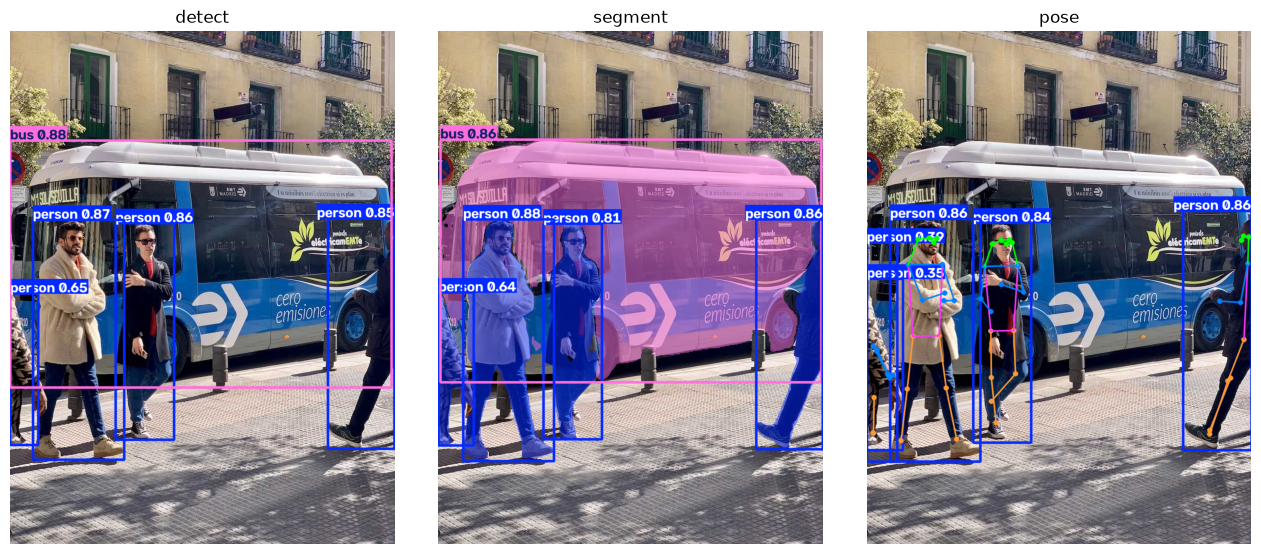

In [2]:
task_models = {task: YOLO(WEIGHTS[f"yolo26n{suffix}.pt"]) for task, suffix in
               [("classify", "-cls"), ("detect", ""), ("segment", "-seg"), ("pose", "-pose")]}
task_results = {task: m.predict(BUS, device="cpu", verbose=False)[0] for task, m in task_models.items()}

cls_r, det_r, seg_r, pose_r = (task_results[t] for t in ("classify", "detect", "segment", "pose"))
print(f"image (H, W): {det_r.orig_shape}")
print(f"classification → top-3 ImageNet labels: {[cls_r.names[i] for i in cls_r.probs.top5[:3]]} "
      f"(top-1 confidence {float(cls_r.probs.top1conf):.2f})")
print(f"detection      → boxes.data {tuple(det_r.boxes.data.shape)}: one row (x1, y1, x2, y2, conf, class) per object → {det_r.verbose().strip(', ')}")
print(f"segmentation   → masks.data {tuple(seg_r.masks.data.shape)}: one binary mask per object")
print(f"pose           → keypoints.data {tuple(pose_r.keypoints.data.shape)}: people × 17 joints × (x, y, visibility)")

fig, axes = plt.subplots(1, 3, figsize=(13, 5.5))
for ax, task in zip(axes, ["detect", "segment", "pose"]):
    ax.imshow(task_results[task].plot()[..., ::-1])            # .plot() returns a BGR image (OpenCV order) → flip to RGB
    ax.set_title(task)
    ax.axis("off")
plt.tight_layout()
plt.show()
del task_models
free_memory()

Notice that the classifier's top labels describe the *whole scene*, while the detector finds every person separately — this is exactly why you need detection when there can be several objects.

> 💡 **Interview angle:** "Semantic vs instance segmentation?" — semantic segmentation labels every pixel with a class (all people share one label); instance segmentation separates each object (person 1, person 2). Mask R-CNN and `yolo26n-seg` do *instance* segmentation: detection plus a mask per box.

## 2. Box Formats and Conversions 🟢

The same rectangle can be written in several ways. Mixing them up is one of the most common silent bugs in detection code.

| Format | Numbers | Used by |
|---|---|---|
| **xyxy** | top-left corner, bottom-right corner `(x1, y1, x2, y2)` in pixels | torchvision ops, Pascal VOC, Ultralytics `boxes.xyxy` |
| **cxcywh** ("xywh" in Ultralytics) | centre `(cx, cy)` + width, height in pixels | YOLO internals, `boxes.xywh` |
| **ltwh** | top-left `(x, y)` + width, height | COCO JSON annotations |
| **normalized cxcywh** | cxcywh divided by image width/height → values in 0..1 | **YOLO label `.txt` files**, `boxes.xywhn` |

```
 (x1,y1) ┌──────────┐
         │    ●     │  ● = (cx, cy)      w = x2 - x1,  h = y2 - y1
         └──────────┘ (x2,y2)            normalized: cx / W, cy / H, w / W, h / H
```

In [3]:
def xyxy_to_cxcywh(b):
    b = np.asarray(b, dtype=float)
    return np.stack([(b[..., 0] + b[..., 2]) / 2, (b[..., 1] + b[..., 3]) / 2,
                     b[..., 2] - b[..., 0], b[..., 3] - b[..., 1]], axis=-1)


def cxcywh_to_xyxy(b):
    b = np.asarray(b, dtype=float)
    half_w, half_h = b[..., 2] / 2, b[..., 3] / 2
    return np.stack([b[..., 0] - half_w, b[..., 1] - half_h, b[..., 0] + half_w, b[..., 1] + half_h], axis=-1)


def xyxy_to_ltwh(b):
    b = np.asarray(b, dtype=float)
    return np.stack([b[..., 0], b[..., 1], b[..., 2] - b[..., 0], b[..., 3] - b[..., 1]], axis=-1)


img_h, img_w = det_r.orig_shape
boxes_xyxy = det_r.boxes.xyxy.cpu().numpy()
ours_cxcywh = xyxy_to_cxcywh(boxes_xyxy)
ours_normalized = ours_cxcywh / np.array([img_w, img_h, img_w, img_h])

# Verify against two libraries — never trust your own conversion until it matches a reference
assert np.allclose(ours_cxcywh, det_r.boxes.xywh.cpu().numpy(), atol=1e-3)
assert np.allclose(ours_normalized, det_r.boxes.xywhn.cpu().numpy(), atol=1e-5)
assert np.allclose(ours_cxcywh, box_convert(torch.from_numpy(boxes_xyxy), "xyxy", "cxcywh").numpy(), atol=1e-3)
assert np.allclose(cxcywh_to_xyxy(ours_cxcywh), boxes_xyxy, atol=1e-3)
print("✅ our conversions match Ultralytics and torchvision\n")

first = pd.DataFrame({"xyxy (px)": boxes_xyxy[0].astype(float), "cxcywh (px)": ours_cxcywh[0],
                      "ltwh / COCO (px)": xyxy_to_ltwh(boxes_xyxy[0]), "normalized cxcywh / YOLO label": ours_normalized[0]},
                     index=["value 1", "value 2", "value 3", "value 4"]).round(3)
print(f"the '{det_r.names[int(det_r.boxes.cls[0])]}' box in four formats:")
print(first)

✅ our conversions match Ultralytics and torchvision

the 'bus' box in four formats:
         xyxy (px)  cxcywh (px)  ltwh / COCO (px)  normalized cxcywh / YOLO label
value 1      0.000      401.548             0.000                           0.496
value 2    230.488      490.504           230.488                           0.454
value 3    803.095      803.095           803.095                           0.991
value 4    750.519      520.031           520.031                           0.482


### ✍️ Your Turn

A labeller drew the pixel box `[100, 50, 300, 250]` (xyxy) on a **640 × 480** image (width × height). Write the four numbers that go into a YOLO label file: normalized `[cx, cy, w, h]`.

In [4]:
yolo_label = None  # TODO: your code here
check("yolo_label", yolo_label, [0.3125, 0.3125, 0.3125, 0.4166667],
      hint="Convert to cxcywh first, then divide x-values by the width (640) and y-values by the height (480).")

⏳ yolo_label: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
yolo_label = xyxy_to_cxcywh([100, 50, 300, 250]) / np.array([640, 480, 640, 480])
check("yolo_label", yolo_label, [0.3125, 0.3125, 0.3125, 0.4166667])
```

Width and height are both 200 px, but they normalize to different numbers because the image is wider than it is tall.
</details>

> 💡 **Interview angle:** "Your detector trains but mAP stays near zero — first thing to check?" — the label format: are the coordinates normalized, centre-based, and in the order the framework expects? Draw a few ground-truth boxes on their images before training anything.

## 3. IoU: Measuring Box Overlap 🟢

**Intersection over Union (IoU)** measures how much two boxes overlap:

$$\text{IoU}(A, B) = \frac{\text{area}(A \cap B)}{\text{area}(A \cup B)} = \frac{\text{intersection}}{\text{area}(A) + \text{area}(B) - \text{intersection}}$$

It is 0 when the boxes don't touch and 1 when they are identical. IoU is used three times in a detector: to decide whether a prediction **matches** a ground-truth box (evaluation), to **remove duplicates** (NMS), and inside the **box loss** during training.

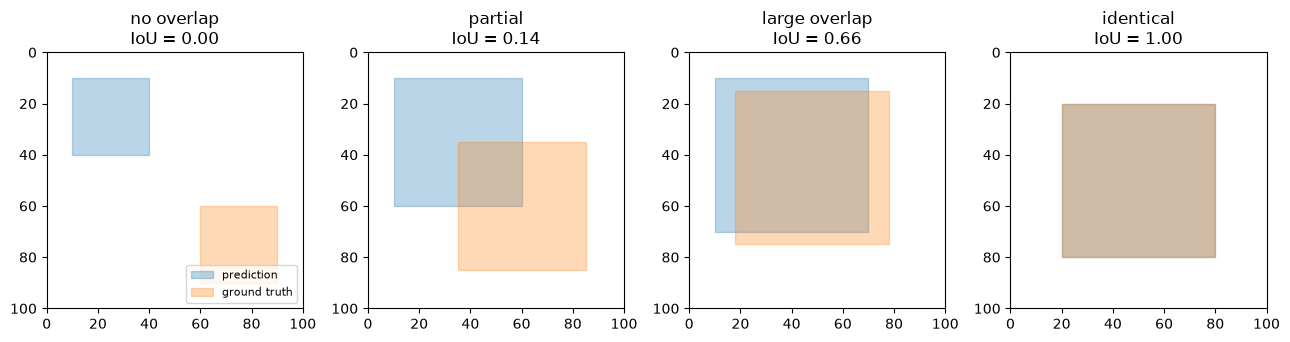

200×200 px box shifted by 10 px → IoU 0.905
 50×50 px box shifted by 10 px → IoU 0.667
 20×20 px box shifted by 10 px → IoU 0.333


In [5]:
def iou_pair(a, b):
    """IoU of two xyxy boxes (plain Python — the vectorized version is in 'Build It From Scratch')."""
    inter_w = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    inter_h = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    inter = inter_w * inter_h
    union = (a[2] - a[0]) * (a[3] - a[1]) + (b[2] - b[0]) * (b[3] - b[1]) - inter
    return inter / union if union > 0 else 0.0


scenarios = [("no overlap", [10, 10, 40, 40], [60, 60, 90, 90]),
             ("partial", [10, 10, 60, 60], [35, 35, 85, 85]),
             ("large overlap", [10, 10, 70, 70], [18, 15, 78, 75]),
             ("identical", [20, 20, 80, 80], [20, 20, 80, 80])]
fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
for ax, (title, a, b) in zip(axes, scenarios):
    for box, color, label in [(a, "tab:blue", "prediction"), (b, "tab:orange", "ground truth")]:
        ax.add_patch(Rectangle((box[0], box[1]), box[2] - box[0], box[3] - box[1], fill=True, alpha=0.3, color=color, label=label))
    ax.set(xlim=(0, 100), ylim=(100, 0), aspect="equal", title=f"{title}\nIoU = {iou_pair(a, b):.2f}")
axes[0].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

# The same 10-pixel mistake hurts small objects much more
for size in [200, 50, 20]:
    print(f"{size:>3}×{size} px box shifted by 10 px → IoU {iou_pair([0, 0, size, size], [10, 0, size + 10, size]):.3f}")

That last printout is why detectors struggle with **small objects**: a few pixels of error can push IoU below the 0.5 matching threshold.

### ✍️ Your Turn

Compute the IoU of `[0, 0, 10, 10]` and `[5, 5, 15, 15]` with `iou_pair` (then check it by hand: intersection 5×5 = 25, union 100 + 100 − 25).

In [6]:
iou_value = None  # TODO: your code here
check("iou_value", iou_value, 25 / 175, hint="iou_pair([0, 0, 10, 10], [5, 5, 15, 15])")

⏳ iou_value: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
iou_value = iou_pair([0, 0, 10, 10], [5, 5, 15, 15])
check("iou_value", iou_value, 25 / 175)
```

≈ 0.143. Half the width and half the height overlap, but the IoU is only 1/7 — IoU drops fast.
</details>

> 💡 **Interview angle:** "Why not train boxes with plain IoU loss?" — when boxes don't overlap, IoU is 0 no matter how far apart they are, so the gradient is zero. **GIoU** adds a penalty using the smallest enclosing box, **DIoU/CIoU** add centre distance (and aspect ratio). Ultralytics' box loss uses **CIoU** (plus DFL for YOLO11, or an L1 term for the DFL-free YOLO26).

## 4. Non-Maximum Suppression 🟡

A detector predicts a box at **thousands** of grid positions. Several neighbouring positions all "see" the same person, so you get a cluster of near-duplicate boxes. **Non-maximum suppression (NMS)** cleans this up:

1. Drop candidates whose confidence is below `conf` (e.g. 0.25).
2. Sort the rest by confidence, highest first.
3. Keep the top box; delete every remaining box whose IoU with it is **above** the `iou` threshold (e.g. 0.7).
4. Repeat with the next surviving box until none are left.

Usually NMS runs **per class** ("class-aware"), so a person box never suppresses a bus box. Let's watch it happen on **real raw predictions** from YOLO11n (a model that needs NMS). We letterbox the photo to 640×640 ourselves, run only the network, and apply NMS by hand with `torchvision`.

raw predictions from the network  : 8,400
after confidence > 0.25           : 47
after class-aware NMS (IoU > 0.7) : 5  → Counter({'person': 4, 'bus': 1})
Ultralytics predict, same image   : 5 boxes → same count as our hand-made pipeline ✅
duplicates removed per kept box   : [9, 9, 9, 8, 7]


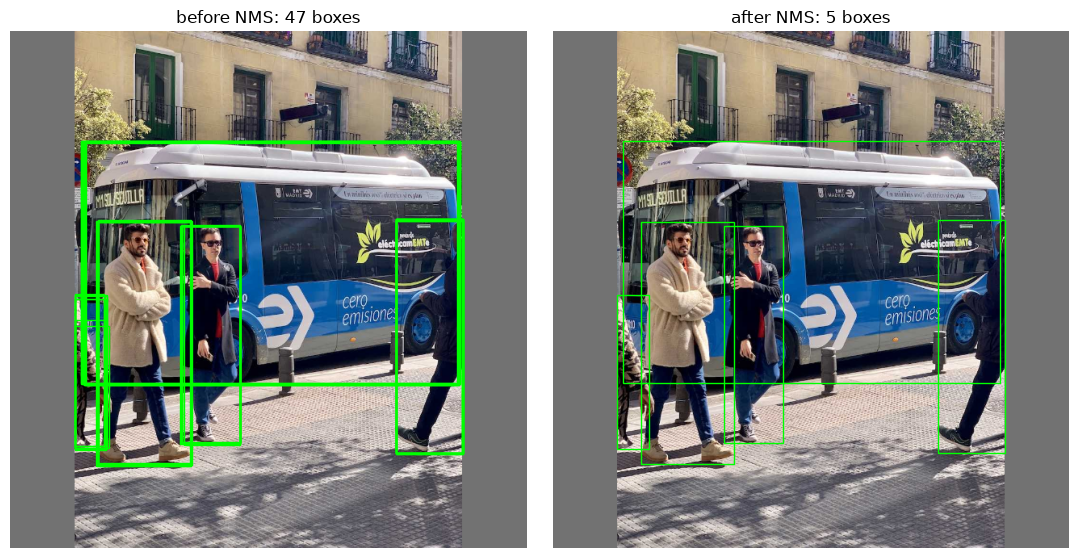

In [7]:
def letterbox(img, size=640, pad_value=114):
    """Resize keeping the aspect ratio, then pad to size×size (what YOLO does before inference)."""
    h, w = img.shape[:2]
    scale = size / max(h, w)
    new_h, new_w = round(h * scale), round(w * scale)
    canvas = np.full((size, size, 3), pad_value, dtype=np.uint8)
    top, left = (size - new_h) // 2, (size - new_w) // 2
    canvas[top:top + new_h, left:left + new_w] = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    return canvas, scale, (left, top)


nms_model = YOLO(WEIGHTS["yolo11n.pt"])
canvas, lb_scale, (lb_left, lb_top) = letterbox(cv2.imread(str(BUS)))
x = torch.from_numpy(canvas[..., ::-1].copy()).permute(2, 0, 1)[None].float() / 255     # BGR→RGB, HWC→CHW, 0..1

with torch.inference_mode():
    raw = nms_model.model.eval()(x)[0][0]                     # (4 + 80, 8400): box (cx, cy, w, h) + 80 class scores per location
scores, classes = raw[4:].max(dim=0)                          # best class and its score for each of the 8,400 locations
print(f"raw predictions from the network  : {raw.shape[1]:,}")

keep_conf = scores > 0.25
cand_boxes = box_convert(raw[:4].T[keep_conf], "cxcywh", "xyxy")
cand_scores, cand_classes = scores[keep_conf], classes[keep_conf]
print(f"after confidence > 0.25           : {len(cand_scores)}")

kept = tv_batched_nms(cand_boxes, cand_scores, cand_classes, iou_threshold=0.7)
print(f"after class-aware NMS (IoU > 0.7) : {len(kept)}  → {Counter(nms_model.names[int(c)] for c in cand_classes[kept])}")

library = nms_model.predict(canvas, conf=0.25, iou=0.7, imgsz=640, device="cpu", verbose=False)[0]
print(f"Ultralytics predict, same image   : {len(library.boxes)} boxes → "
      + ("same count as our hand-made pipeline ✅" if len(library.boxes) == len(kept) else "counts differ (preprocessing details differ)"))

duplicates = (tv_box_iou(cand_boxes[kept], cand_boxes) > 0.5).sum(dim=1) - 1
print(f"duplicates removed per kept box   : {duplicates.tolist()}")

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))
for ax, (title, boxes) in zip(axes, [(f"before NMS: {len(cand_boxes)} boxes", cand_boxes), (f"after NMS: {len(kept)} boxes", cand_boxes[kept])]):
    ax.imshow(canvas[..., ::-1])
    for x1, y1, x2, y2 in boxes.tolist():
        ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=1, color="lime"))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

Compare the last two counts: network → confidence filter → `batched_nms` is essentially all of YOLO11's post-processing. NMS is not magic — it is about ten lines of code.

**Where NMS fails:** two people standing close together really do have overlapping boxes. A low `iou` threshold merges them into one detection (missed person); a high threshold keeps more duplicates. Fixes: **Soft-NMS** (lower the scores of overlapping boxes instead of deleting them) or **NMS-free** detectors (DETR, YOLOv10, YOLO26) that learn to output one box per object.

### ✍️ Your Turn

Three boxes with scores `[0.9, 0.8, 0.7]` (already sorted). Which indices survive NMS at IoU threshold 0.5? Use `tv_nms` and store the kept indices as a Python list.

In [8]:
toy_boxes = torch.tensor([[0, 0, 10, 10], [1, 1, 11, 11], [20, 20, 30, 30]], dtype=torch.float32)
toy_scores = torch.tensor([0.9, 0.8, 0.7])
kept_idx = None  # TODO: your code here
check("kept_idx", kept_idx, [0, 2], hint="tv_nms(boxes, scores, iou_threshold) returns a tensor of kept indices; call .tolist().")

⏳ kept_idx: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
toy_boxes = torch.tensor([[0, 0, 10, 10], [1, 1, 11, 11], [20, 20, 30, 30]], dtype=torch.float32)
toy_scores = torch.tensor([0.9, 0.8, 0.7])
kept_idx = tv_nms(toy_boxes, toy_scores, 0.5).tolist()
check("kept_idx", kept_idx, [0, 2])
```

Boxes 0 and 1 overlap with IoU 81 / 119 ≈ 0.68 > 0.5, so the lower-scoring box 1 is removed; box 2 doesn't overlap anything.
</details>

> 💡 **Interview angle:** "What is the complexity of NMS and how do you make it class-aware cheaply?" — greedy NMS is O(n²) in the worst case. For class-aware NMS in one call, add `class_id × (max_coordinate + 1)` to every box so boxes of different classes can never overlap, then run plain NMS once (the "offset trick" `batched_nms` uses).

## 5. Inside YOLO: Grids, Anchor-Free Heads, DFL, and NMS-Free Detection 🟡

**The three parts of every modern YOLO**

| Part | Job | In YOLO11 / YOLO26 |
|---|---|---|
| **Backbone** | turn pixels into feature maps, downsampling by 2 each stage | strided `Conv` layers + `C3k2` (CSP-style) blocks, `SPPF` (fast spatial pyramid pooling), `C2PSA` (attention) |
| **Neck** | mix fine (small-object) and coarse (large-object) features | FPN top-down path (upsample + concat) then PAN bottom-up path (strided conv + concat) |
| **Head** | predict boxes and classes at every location of three feature maps (strides 8, 16, 32) | **decoupled**: one branch for the box (`cv2`), a separate branch for classes (`cv3`) |

**Grids.** At 640×640 the three feature maps are 80×80, 40×40 and 20×20, so the head makes 6,400 + 1,600 + 400 = **8,400** predictions. Small objects are found on the fine 80×80 map, large ones on the coarse 20×20 map.

**Anchor-based vs anchor-free.**
- *Anchor-based* detectors (Faster R-CNN, YOLOv2–v7) place several hand-designed **anchor boxes** (preset shapes) at every cell and predict *offsets* from them. You must tune anchor sizes to your dataset.
- *Anchor-free* detectors (FCOS, YOLOX, YOLOv8, YOLO11, YOLO26) predict, at each grid point, the **distances to the four box sides** (left, top, right, bottom). No anchor shapes to tune, fewer predictions.

**No objectness score.** YOLOv3–v5 had a separate "is there any object here?" output. The YOLOv8/11/26 heads have **only** a box branch and a class branch — each class score already means "object of this class here". Let's check the real heads instead of trusting a diagram.

In [9]:
arch_models = {"YOLO11n": YOLO(WEIGHTS["yolo11n.pt"]), "YOLO26n": YOLO(WEIGHTS["yolo26n.pt"])}
arch_rows = {}
for family, m in arch_models.items():
    head = m.model.model[-1]
    with torch.inference_mode():
        out = m.model.eval()(torch.zeros(1, 3, 640, 640))[0]
    arch_rows[family] = {
        "parameters (millions)": round(sum(p.numel() for p in m.model.parameters()) / 1e6, 2),
        "strides": head.stride.int().tolist(),
        "head sub-modules": [name for name, _ in head.named_children()],
        "box channels per location (cv2)": head.cv2[0][-1].out_channels,
        "class channels per location (cv3)": head.cv3[0][-1].out_channels,
        "DFL bins (reg_max)": head.reg_max,
        "decoded predictions at 640": out.shape[-1],
    }
print(pd.DataFrame(arch_rows))
print("\ngrid points at 640:", " + ".join(f"{640 // s}²" for s in (8, 16, 32)), "=", sum((640 // s) ** 2 for s in (8, 16, 32)))
print("YOLO26n layer types:", dict(Counter(type(layer).__name__ for layer in arch_models["YOLO26n"].model.model)))

                                           YOLO11n                                    YOLO26n
parameters (millions)                         2.62                                       2.57
strides                                [8, 16, 32]                                [8, 16, 32]
head sub-modules                   [cv2, cv3, dfl]  [cv2, cv3, dfl, one2one_cv2, one2one_cv3]
box channels per location (cv2)                 64                                          4
class channels per location (cv3)               80                                         80
DFL bins (reg_max)                              16                                          1
decoded predictions at 640                    8400                                       8400

grid points at 640: 80² + 40² + 20² = 8400
YOLO26n layer types: {'Conv': 7, 'C3k2': 8, 'SPPF': 1, 'C2PSA': 1, 'Upsample': 2, 'Concat': 4, 'Detect': 1}


Reading the table: YOLO11's box branch outputs **64 = 4 sides × 16 bins** per location; YOLO26's outputs just **4**. Both have 80 class channels and no objectness channel. YOLO26 also has extra `one2one_*` branches — its NMS-free head.

**Distribution Focal Loss (DFL).** Instead of predicting one number for "distance to the left side", YOLO11 predicts a **probability distribution over 16 bins** (0, 1, …, 15 grid units) and uses its **expected value**. A blurry edge can then be expressed as "somewhere between 6 and 7" — this came from the Generalized Focal Loss paper. Here is the idea in four lines, checked against Ultralytics' own `DFL` module:

In [10]:
from ultralytics.nn.modules.block import DFL

logits = torch.randn(1, 4 * 16, 1, generator=torch.Generator().manual_seed(0))    # 1 image, 4 sides × 16 bins, 1 location
probs = logits.view(1, 4, 16, 1).softmax(dim=2)                                     # a distribution per side
expected_distance = (probs * torch.arange(16.0).view(1, 1, 16, 1)).sum(dim=2)       # expected bin index per side
assert torch.allclose(DFL(16)(logits), expected_distance, atol=1e-5)
print("left-side bin probabilities:", probs[0, 0, :, 0].numpy().round(2))
print("expected distances (l, t, r, b) in grid units:", expected_distance.flatten().numpy().round(2), "✅ matches ultralytics DFL")

left-side bin probabilities: [0.02 0.02 0.04 0.03 0.12 0.1  0.04 0.01 0.07 0.01 0.07 0.07 0.06 0.17 0.15 0.04]
expected distances (l, t, r, b) in grid units: [9.15 8.8  9.12 9.65] ✅ matches ultralytics DFL


**YOLO26 — what changed (verified in this install).**
- `reg_max: 1` in `yolo26.yaml`: **DFL removed** — one number per side, simpler to export and quantize (the box loss uses an L1 term instead of DFL).
- `end2end: True`: a **one-to-one head** trained to output a single box per object (the dual-assignment idea from YOLOv10), so NMS can be skipped. In end-to-end mode the network directly returns the top 300 boxes:

In [11]:
yolo26_arch = arch_models["YOLO26n"]
yolo26_arch.model.end2end = True
with torch.inference_mode():
    e2e_out = yolo26_arch.model.eval()(torch.zeros(1, 3, 640, 640))
e2e_out = e2e_out[0] if isinstance(e2e_out, (tuple, list)) else e2e_out
yolo26_arch.model.end2end = False
print(f"YOLO26n end-to-end output: {tuple(e2e_out.shape)} = (batch, max boxes, x1 y1 x2 y2 conf class) — nothing left for NMS to do")
del arch_models, yolo26_arch
free_memory()

YOLO26n end-to-end output: (1, 300, 6) = (batch, max boxes, x1 y1 x2 y2 conf class) — nothing left for NMS to do


⚠️ **Version detail that matters:** in ultralytics 8.4.150, `predict`/`val` use the `nms` argument — `nms=None` (the default) runs YOLO26's one-to-many head **with** NMS, and **`nms=False` selects the NMS-free one-to-one head**. Section 9 measures the difference.

The optimizer `MuSGD` (a Muon + SGD hybrid) is another YOLO26-era addition; Ultralytics' `optimizer="auto"` picks it only for long schedules (> 10,000 iterations) — see Section 12.

### ✍️ Your Turn

How many predictions does the head make for a **320×320** input (strides 8, 16, 32)? Compute it with a formula, not by hand.

In [12]:
n_pred_320 = None  # TODO: your code here
check("n_pred_320", n_pred_320, 2100, hint="sum((320 // s) ** 2 for s in (8, 16, 32))")

⏳ n_pred_320: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_pred_320 = sum((320 // s) ** 2 for s in (8, 16, 32))
check("n_pred_320", n_pred_320, 2100)
```

40² + 20² + 10² = 2,100 — four times fewer than at 640, which is one reason smaller `imgsz` is faster (the other is 4× fewer pixels through the backbone).
</details>

> 💡 **Interview angle:** "Does YOLOv8/YOLO11 predict objectness?" — no: the head is decoupled into a box-regression branch (DFL distribution over 4 side distances) and a classification branch; there is no objectness output. "Why decoupled?" — classification and localization want different features, and separating them converges faster and more accurately.

## 6. One-Stage vs Two-Stage Detectors (and DETR) 🟡

**Two-stage (R-CNN family)** — "first propose, then classify":
1. A **backbone + FPN** (Feature Pyramid Network) builds feature maps at several scales. FPN adds a top-down path with lateral connections, so even the high-resolution maps carry strong semantic features — crucial for small objects.
2. The **RPN** (Region Proposal Network) slides over the features with **anchors** and proposes ~1,000–2,000 regions that might contain *something*.
3. For each proposal, **RoI Pool / RoI Align** crops a fixed-size (e.g. 7×7) feature patch from the right pyramid level.
4. A second head **classifies** each region and **refines** its box. **Mask R-CNN** adds a third small branch that predicts a 28×28 **mask** per region (instance segmentation).

**One-stage (YOLO, SSD, RetinaNet, FCOS)** — "predict everything at every location at once": no proposal step, one dense head, then NMS (or no NMS for end-to-end heads). Historically less accurate on small objects; modern YOLOs closed most of that gap while staying much faster.

**Transformers (DETR, RT-DETR)** treat detection as **set prediction**: a fixed number of learned queries each output one box, trained with **Hungarian matching** so exactly one query matches each object — no anchors and no NMS. The original DETR converged slowly; **RT-DETR** made it real-time. Ultralytics can load RT-DETR with `RTDETR("rtdetr-l.pt")` (not downloaded here: ~60 MB+).

**Why RoI Align replaced RoI Pool.** RoI Pool **rounds** the region's coordinates to whole feature cells, so a box that moves by a fraction of a cell produces exactly the same features — fine for classification, bad for pixel-accurate masks. RoI Align samples with **bilinear interpolation** at exact positions. Measured on a tiny feature map:

In [13]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn
from torchvision.ops import roi_align, roi_pool

feature = torch.arange(64, dtype=torch.float32).view(1, 1, 8, 8)      # a tiny 8×8 feature map holding 0..63
for shift in [0.0, 0.2]:
    roi = torch.tensor([[0, 1.2 + shift, 1.2, 5.2 + shift, 5.2]])        # (batch index, x1, y1, x2, y2) with fractional coordinates
    pooled = roi_pool(feature, roi, output_size=2, spatial_scale=1.0).flatten().tolist()
    aligned = roi_align(feature, roi, output_size=2, spatial_scale=1.0, sampling_ratio=2, aligned=True).flatten().tolist()
    print(f"box shifted right by {shift:.1f} cell → RoI Pool {pooled} | RoI Align {[round(v, 2) for v in aligned]}")

box shifted right by 0.0 cell → RoI Pool [27.0, 29.0, 43.0, 45.0] | RoI Align [15.3, 17.3, 31.3, 33.3]
box shifted right by 0.2 cell → RoI Pool [27.0, 29.0, 43.0, 45.0] | RoI Align [15.5, 17.5, 31.5, 33.5]


RoI Pool gives identical numbers for both boxes; RoI Align notices the 0.2-cell shift.

**Size and speed, measured.** torchvision's Faster R-CNN (ResNet-50 + FPN) built with **untrained weights** (`weights=None`, so nothing is downloaded — we only measure size and CPU time, not accuracy) vs YOLO26n, both on a 640×640 input:

In [14]:
def median_ms(fn, runs=3):
    fn()                                                              # warm-up call
    times = []
    for _ in range(runs):
        start = time.perf_counter()
        fn()
        times.append((time.perf_counter() - start) * 1000)
    return float(np.median(times))


frcnn = fasterrcnn_resnet50_fpn(weights=None, weights_backbone=None, min_size=640, max_size=640).eval()
yolo_net = YOLO(WEIGHTS["yolo26n.pt"]).model.eval()
image_640 = torch.rand(3, 640, 640, generator=torch.Generator().manual_seed(0))
with torch.inference_mode():
    frcnn_ms = median_ms(lambda: frcnn([image_640]))
    yolo_ms = median_ms(lambda: yolo_net(image_640[None]))
size_rows = pd.DataFrame({
    "parameters (M)": [sum(p.numel() for p in frcnn.parameters()) / 1e6, sum(p.numel() for p in yolo_net.parameters()) / 1e6],
    "CPU forward (ms)": [frcnn_ms, yolo_ms],
}, index=["Faster R-CNN R50-FPN (two-stage)", "YOLO26n (one-stage)"]).round(1)
print(size_rows)
print(f"→ YOLO26n is {size_rows.iloc[0, 0] / size_rows.iloc[1, 0]:.0f}× smaller and {frcnn_ms / yolo_ms:.0f}× faster on this CPU "
      "(a fair accuracy comparison needs trained weights of similar size — the n model is the smallest YOLO).")
del frcnn, yolo_net
free_memory()

                                  parameters (M)  CPU forward (ms)
Faster R-CNN R50-FPN (two-stage)            41.8             395.0
YOLO26n (one-stage)                          2.6              30.7
→ YOLO26n is 16× smaller and 13× faster on this CPU (a fair accuracy comparison needs trained weights of similar size — the n model is the smallest YOLO).


**About Detectron2:** Meta's Detectron2 is the classic research codebase for Faster/Mask R-CNN. It has no official pip wheels for recent PyTorch versions or macOS and must be compiled against your exact PyTorch build, so this course doesn't use it. For two-stage models today, `torchvision.models.detection` (Faster/Mask R-CNN, RetinaNet, FCOS) or MMDetection are the practical options.

> 💡 **Interview angle:** "When would you still pick a two-stage detector?" — offline, accuracy-critical work with small or crowded objects (medical, satellite, document layout), or when you need Mask R-CNN-style masks with a mature research codebase. For real-time video on edge devices, one-stage YOLO-style models (or RT-DETR on a GPU) win.

## 7. Pretrained Inference and the Results Object 🟢

`model.predict(source)` accepts a path, a folder, a URL, a video, a NumPy image (BGR), or a list of them, and returns a **list of `Results`** — one per image. For videos and long lists pass `stream=True` to get a **generator** instead, so results are not all kept in memory.

| `Results` attribute | What it holds |
|---|---|
| `r.boxes` | a `Boxes` object: `.xyxy`, `.xywh`, `.xyxyn`, `.xywhn`, `.conf`, `.cls`, `.id` (track IDs, or `None`), `.data` (N×6) |
| `r.names` | `{class_id: class_name}` |
| `r.orig_shape` | original image `(height, width)` |
| `r.speed` | milliseconds for `preprocess`, `inference`, `postprocess` |
| `r.plot()` | annotated image as a **BGR** NumPy array |
| `r.summary()` / `r.to_df()` | detections as a list of dicts / a (polars) DataFrame |
| `r.masks`, `r.keypoints`, `r.probs`, `r.obb` | filled for segmentation, pose, classification, oriented boxes |

first call on mps (builds the predictor, moves weights, warms up): 334 ms wall time



bus.jpg    (H, W)=(1080, 810) | 4 persons, 1 bus     | preprocess 0.9 ms | inference 5.6 ms | postprocess 1.7 ms | total 8.3 ms → 121 images/s
zidane.jpg (H, W)=(720, 1280) | 2 persons, 1 tie     | preprocess 1.1 ms | inference 7.0 ms | postprocess 4.5 ms | total 12.6 ms → 80 images/s

zidane.jpg Boxes: 3 boxes | is_track=False | id=None
xyxy (pixels):
 [[ 742.    40.1 1150.7  708.5]
 [ 119.   201.8 1002.2  712.8]
 [ 436.3  434.6  526.   715.8]]
xywhn (normalized):
 [[0.739 0.52  0.319 0.928]
 [0.438 0.635 0.69  0.71 ]
 [0.376 0.799 0.07  0.391]]
conf: [0.892 0.843 0.585] | classes: ['person', 'person', 'tie']

as a table:
      name  class  confidence  box.x1  box.y1  box.x2  box.y2
0  person      0         0.9   742.0    40.1  1150.7   708.5
1  person      0         0.8   119.0   201.8  1002.2   712.8
2     tie     27         0.6   436.3   434.6   526.0   715.8


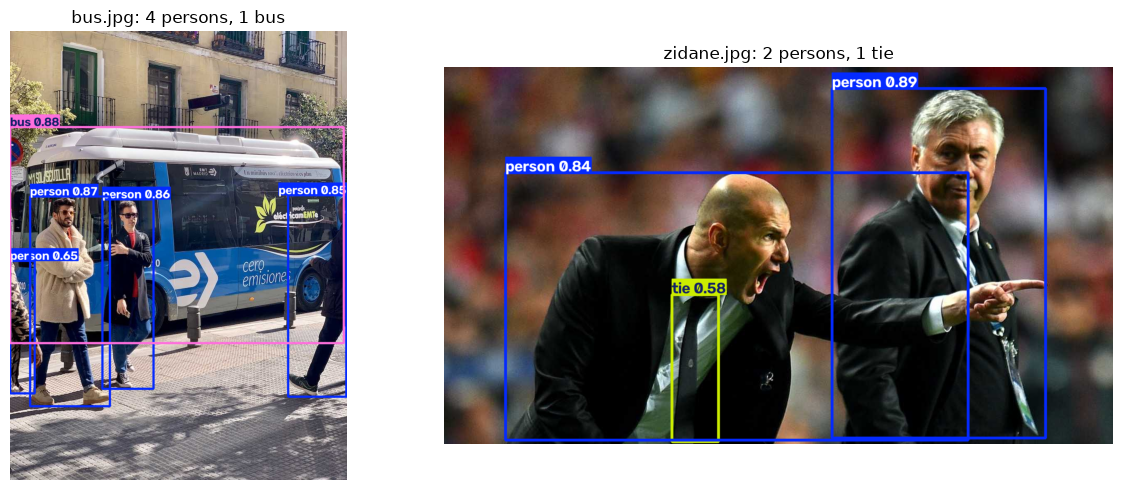

In [15]:
model = YOLO(WEIGHTS["yolo26n.pt"])
start = time.perf_counter()
model.predict(BUS, device=DEVICE, verbose=False)
print(f"first call on {DEVICE} (builds the predictor, moves weights, warms up): {(time.perf_counter() - start) * 1000:.0f} ms wall time\n")

results = []
for source in [BUS, ZIDANE]:
    model.predict(source, conf=0.25, device=DEVICE, verbose=False)            # warm-up for this image size
    results.append(model.predict(source, conf=0.25, device=DEVICE, verbose=False)[0])
for r in results:
    total_ms = sum(r.speed.values())
    print(f"{Path(r.path).name:10s} (H, W)={r.orig_shape} | {r.verbose().strip(', '):20s} | "
          + " | ".join(f"{k} {v:.1f} ms" for k, v in r.speed.items()) + f" | total {total_ms:.1f} ms → {1000 / total_ms:.0f} images/s")

z = results[1]
print(f"\nzidane.jpg Boxes: {len(z.boxes)} boxes | is_track={z.boxes.is_track} | id={z.boxes.id}")
print("xyxy (pixels):\n", z.boxes.xyxy.cpu().numpy().round(1))
print("xywhn (normalized):\n", z.boxes.xywhn.cpu().numpy().round(3))
print("conf:", z.boxes.conf.cpu().numpy().round(3), "| classes:", [z.names[int(c)] for c in z.boxes.cls])
print("\nas a table:\n", pd.json_normalize(z.summary()).round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, r in zip(axes, results):
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(f"{Path(r.path).name}: {r.verbose().strip(', ')}")
    ax.axis("off")
plt.tight_layout()
plt.show()

Notice the `speed` numbers are **milliseconds per image**. Throughput is `1000 / total_ms` images per second — an image that takes 80 ms end-to-end runs at 12.5 FPS, *not* 80 FPS.

> 💡 **Interview angle:** "How do you report a detector's speed?" — per-stage latency (preprocess / inference / postprocess) in ms, measured after warm-up, with device, image size, batch size and precision stated; FPS = 1000 / total ms for batch 1. Inference-only numbers hide the cost of NMS and image decoding.

## 8. Precision–Recall Curves and mAP 🟡

**When is a prediction correct?** A predicted box is a **true positive (TP)** if it has the right class and IoU ≥ a threshold (e.g. 0.5) with a ground-truth box that hasn't already been matched. Otherwise it is a **false positive (FP)**. Ground-truth boxes left unmatched are **false negatives (FN)**.

- **Precision** = TP / (TP + FP) — "of the boxes I drew, how many were right?"
- **Recall** = TP / (TP + FN) — "of the real objects, how many did I find?"

**The precision–recall (PR) curve.** Sort all predictions of a class by confidence. Walk down the list, and after each prediction compute precision and recall so far. Lowering the threshold finds more objects (recall ↑) but lets in more mistakes (precision usually ↓).

**Average precision (AP)** is the area under that curve (after making precision monotonically decreasing — the "envelope"). **mAP** is the mean of AP over classes.

| Metric | Meaning |
|---|---|
| **mAP@0.5** (`mAP50`) | IoU threshold 0.5 — the Pascal VOC-style metric; "did you find it roughly?" |
| **mAP@0.5:0.95** (`mAP50-95`) | average of mAP at IoU 0.50, 0.55, …, 0.95 (10 thresholds) — the **COCO primary metric**; rewards tight boxes |

Details differ between tools: COCO's official code averages precision at 101 recall points, Pascal VOC 2007 used 11 points, and Ultralytics integrates a 101-point interpolated curve with the trapezoid rule. Always compare numbers produced by the **same** evaluator.

**Real experiment.** The COCO-pretrained YOLO26n knows `elephant` and `zebra` but has never seen the **African Wildlife** dataset. We run it on the dataset's 225 **validation** images and evaluate those two classes with Ultralytics' own matching and AP functions. (We'll rebuild both from scratch later and prove they agree.)

In [16]:
from ultralytics.models.yolo.detect import DetectionValidator
from ultralytics.utils.metrics import ap_per_class

WILDLIFE_NAMES = {0: "buffalo", 1: "elephant", 2: "rhino", 3: "zebra"}
pretrained = YOLO(WEIGHTS["yolo26n.pt"])
COCO_TO_WILDLIFE = {20: 1, 22: 3}                                   # COCO has elephant and zebra, but no buffalo or rhino
assert pretrained.names[20] == "elephant" and pretrained.names[22] == "zebra"


def label_path_for(image_path):
    """.../images/<split>/name.jpg → .../labels/<split>/name.txt"""
    p = Path(image_path)
    return p.parents[2] / "labels" / p.parent.name / f"{p.stem}.txt"


def load_labels(image_path, width, height):
    """Ground-truth boxes of one image as pixel xyxy + class ids."""
    path = label_path_for(image_path)
    if not path.exists() or path.stat().st_size == 0:
        return np.zeros((0, 4)), np.zeros(0, dtype=int)
    lab = np.loadtxt(path, ndmin=2)
    return cxcywh_to_xyxy(lab[:, 1:5] * np.array([width, height, width, height])), lab[:, 0].astype(int)


def collect_predictions(model, image_paths, imgsz, device=EVAL_DEVICE, conf=0.001, **kwargs):
    """Predict one image at a time and keep only small NumPy arrays (predictions + ground truth).

    Passing a Python *list* of paths to predict() loads every image into RAM first, so we loop instead.
    """
    records = []
    for image_path in image_paths:
        r = model.predict(str(image_path), imgsz=imgsz, conf=conf, device=device, verbose=False, **kwargs)[0]
        h, w = r.orig_shape
        gt_boxes, gt_cls = load_labels(r.path, w, h)
        records.append(dict(image=Path(r.path).name, pred_boxes=r.boxes.xyxy.cpu().numpy().astype(float),
                            pred_scores=r.boxes.conf.cpu().numpy().astype(float),
                            pred_cls=r.boxes.cls.cpu().numpy().astype(int), gt_boxes=gt_boxes, gt_cls=gt_cls))
    return records


def remap(records, class_map):
    """Keep only predictions whose class is in class_map, renamed to the dataset's class ids."""
    out = []
    for rec in records:
        keep = np.isin(rec["pred_cls"], list(class_map))
        out.append({**rec, "pred_boxes": rec["pred_boxes"][keep], "pred_scores": rec["pred_scores"][keep],
                    "pred_cls": np.array([class_map[c] for c in rec["pred_cls"][keep]], dtype=int)})
    return out


_validator = DetectionValidator(save_dir=OUTPUT_DIR / "validator", args=dict(task="detect"))
IOU_THRESHOLDS = _validator.iouv.numpy()                            # 0.50, 0.55, ..., 0.95


def ultralytics_match(records, classes, min_conf=0.0):
    """TP flags (n_pred × 10 IoU thresholds) using Ultralytics' matching, pooled over all images."""
    tps, confs, pred_cls, target_cls = [], [], [], []
    for rec in records:
        keep_p = np.isin(rec["pred_cls"], classes) & (rec["pred_scores"] >= min_conf)
        keep_g = np.isin(rec["gt_cls"], classes)
        pb, pc, gb, gc = rec["pred_boxes"][keep_p], rec["pred_cls"][keep_p], rec["gt_boxes"][keep_g], rec["gt_cls"][keep_g]
        if len(pb) and len(gb):
            correct = _validator.match_predictions(torch.from_numpy(pc), torch.from_numpy(gc),
                                                   tv_box_iou(torch.from_numpy(gb), torch.from_numpy(pb))).numpy()
        else:
            correct = np.zeros((len(pb), len(IOU_THRESHOLDS)), dtype=bool)
        tps.append(correct)
        confs.append(rec["pred_scores"][keep_p])
        pred_cls.append(pc)
        target_cls.append(gc)
    return dict(tp=np.concatenate(tps), conf=np.concatenate(confs), pred_cls=np.concatenate(pred_cls),
                target_cls=np.concatenate(target_cls))


def ultralytics_ap(stats):
    """{class_id: AP at each of the 10 IoU thresholds} from Ultralytics' ap_per_class."""
    out = ap_per_class(stats["tp"], stats["conf"], stats["pred_cls"], stats["target_cls"])
    return {int(c): out[5][i] for i, c in enumerate(out[6])}


val_images = sorted((WILDLIFE / "images" / "val").glob("*.jpg"))
start = time.perf_counter()
val_raw_320 = collect_predictions(pretrained, val_images, imgsz=320)
print(f"predicted {len(val_images)} validation images at 320 px in {time.perf_counter() - start:.1f} s on {EVAL_DEVICE}")

zs_val = remap(val_raw_320, COCO_TO_WILDLIFE)
zs_stats = ultralytics_match(zs_val, classes=[1, 3])
zs_ap = ultralytics_ap(zs_stats)
print(pd.DataFrame([{"class": WILDLIFE_NAMES[c], "GT boxes": int((zs_stats["target_cls"] == c).sum()),
                     "predictions (conf ≥ 0.001)": int((zs_stats["pred_cls"] == c).sum()),
                     "AP@0.5": ap[0], "AP@0.75": ap[5], "AP@0.5:0.95": ap.mean()} for c, ap in zs_ap.items()]).round(3))
print(f"\nzero-shot mAP@0.5 = {np.mean([a[0] for a in zs_ap.values()]):.3f} | "
      f"mAP@0.5:0.95 = {np.mean([a.mean() for a in zs_ap.values()]):.3f} (elephant + zebra only)")

predicted 225 validation images at 320 px in 3.1 s on cpu
      class  GT boxes  predictions (conf ≥ 0.001)  AP@0.5  AP@0.75  AP@0.5:0.95
0  elephant        91                        1239   0.784    0.701        0.654
1     zebra       114                        1194   0.939    0.809        0.755

zero-shot mAP@0.5 = 0.861 | mAP@0.5:0.95 = 0.704 (elephant + zebra only)


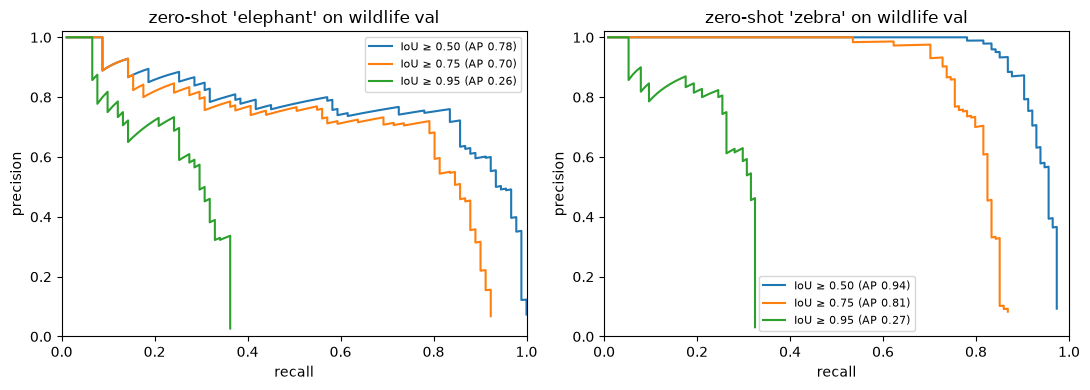

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, c in zip(axes, [1, 3]):
    sel = zs_stats["pred_cls"] == c
    order = np.argsort(-zs_stats["conf"][sel])
    n_gt = int((zs_stats["target_cls"] == c).sum())
    for t_idx in [0, 5, 9]:
        cum_tp = np.cumsum(zs_stats["tp"][sel][order, t_idx])
        ax.plot(cum_tp / n_gt, cum_tp / np.arange(1, len(cum_tp) + 1),
                label=f"IoU ≥ {IOU_THRESHOLDS[t_idx]:.2f} (AP {zs_ap[c][t_idx]:.2f})")
    ax.set(title=f"zero-shot '{WILDLIFE_NAMES[c]}' on wildlife val", xlabel="recall", ylabel="precision", xlim=(0, 1), ylim=(0, 1.02))
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

Each curve starts at high precision (the most confident boxes are almost always right) and drops as recall grows. The stricter the IoU threshold, the lower the curve: at IoU ≥ 0.95 even correct detections rarely line up that precisely — which is exactly what mAP@0.5:0.95 punishes.

### ✍️ Your Turn

A model's AP for one class at the ten COCO IoU thresholds 0.50, 0.55, …, 0.95 is given below. Compute its **AP@0.5:0.95**.

In [18]:
aps_per_threshold = np.array([0.80, 0.78, 0.75, 0.71, 0.66, 0.60, 0.51, 0.40, 0.25, 0.08])
ap_50_95 = None  # TODO: your code here
check("ap_50_95", ap_50_95, 0.554, hint="It is the plain mean over the 10 thresholds.")

⏳ ap_50_95: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
aps_per_threshold = np.array([0.80, 0.78, 0.75, 0.71, 0.66, 0.60, 0.51, 0.40, 0.25, 0.08])
ap_50_95 = aps_per_threshold.mean()
check("ap_50_95", ap_50_95, 0.554)
```

AP@0.5 is 0.80 but AP@0.5:0.95 is only 0.554: this model finds objects well but its boxes are loose.
</details>

> 💡 **Interview angle:** "mAP@0.5 is 0.90 but mAP@0.5:0.95 is 0.45 — what does that tell you?" — the model finds and classifies objects but localizes them loosely. Look at box regression (loss weights, higher input resolution, label quality of box edges) rather than classification.

## 9. Confidence and IoU Thresholds, Measured 🟡

Two knobs control what `predict` returns:

| Argument | Default | Effect |
|---|---|---|
| `conf` | 0.25 for predict, 0.001 for val | minimum score to keep a box — **the precision/recall trade-off** |
| `iou` | 0.7 | NMS threshold — boxes overlapping a better box by more than this are removed |

**Rule:** compute mAP with a very low `conf` (the whole PR curve), but deploy with a threshold chosen **on validation data** for your goal (for example, best F1, or "precision ≥ 0.9"). Let's sweep `conf` on the zero-shot validation predictions — re-matching at every threshold.

 conf  predictions  TP  FP  FN  precision  recall    f1
 0.05          436 197 239   8      0.452   0.961 0.615
 0.10          355 194 161  11      0.546   0.946 0.693
 0.15          316 192 124  13      0.608   0.937 0.737
 0.20          289 188 101  17      0.651   0.917 0.761
 0.25          269 186  83  19      0.691   0.907 0.785
 0.30          254 183  71  22      0.720   0.893 0.797
 0.35          240 178  62  27      0.742   0.868 0.800
 0.40          231 176  55  29      0.762   0.859 0.807
 0.45          225 174  51  31      0.773   0.849 0.809
 0.50          217 171  46  34      0.788   0.834 0.810
 0.55          208 167  41  38      0.803   0.815 0.809
 0.60          204 166  38  39      0.814   0.810 0.812
 0.65          192 162  30  43      0.844   0.790 0.816
 0.70          179 155  24  50      0.866   0.756 0.807
 0.75          165 142  23  63      0.861   0.693 0.768
 0.80          147 127  20  78      0.864   0.620 0.722
 0.85          113 100  13 105      0.885   0.48

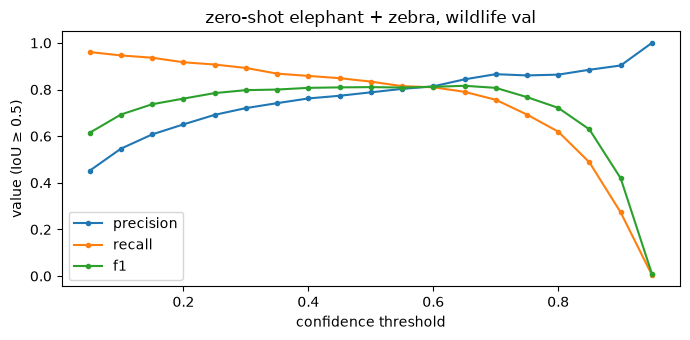

In [19]:
def pr_counts(records, classes, min_conf, iou_index=0):
    stats = ultralytics_match(records, classes, min_conf=min_conf)
    tp, n_pred, n_gt = int(stats["tp"][:, iou_index].sum()), len(stats["tp"]), len(stats["target_cls"])
    precision = tp / n_pred if n_pred else 1.0
    recall = tp / n_gt
    return dict(conf=min_conf, predictions=n_pred, TP=tp, FP=n_pred - tp, FN=n_gt - tp, precision=precision, recall=recall,
                f1=2 * precision * recall / (precision + recall) if tp else 0.0)


sweep = pd.DataFrame([pr_counts(zs_val, [1, 3], t) for t in np.round(np.arange(0.05, 0.96, 0.05), 2)])
_best_conf_ref = float(sweep.loc[sweep["f1"].idxmax(), "conf"])
print(sweep.round(3).to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 3.5))
for col in ["precision", "recall", "f1"]:
    ax.plot(sweep["conf"], sweep[col], marker="o", ms=3, label=col)
ax.set(xlabel="confidence threshold", ylabel="value (IoU ≥ 0.5)", title="zero-shot elephant + zebra, wildlife val")
ax.legend()
plt.tight_layout()
plt.show()

Now the NMS `iou` threshold. We take 60 random validation images and run three set-ups at `conf=0.25` with different `iou` values: YOLO11n (always NMS), YOLO26n with the default `nms=None` (one-to-many head + NMS), and YOLO26n with `nms=False` (one-to-one head, no NMS).

In [20]:
sample_images = [val_images[i] for i in sorted(rng.choice(len(val_images), size=60, replace=False))]
nms_setups = [("YOLO11n (NMS)", WEIGHTS["yolo11n.pt"], {}),
              ("YOLO26n nms=None (NMS)", WEIGHTS["yolo26n.pt"], {}),
              ("YOLO26n nms=False (NMS-free)", WEIGHTS["yolo26n.pt"], {"nms": False})]
nms_rows = []
for setup_name, weights, extra in nms_setups:
    setup_model = YOLO(weights)                                      # a fresh model per set-up
    for iou in [0.3, 0.5, 0.7, 0.9]:
        start = time.perf_counter()
        recs = remap(collect_predictions(setup_model, sample_images, imgsz=320, conf=0.25, iou=iou, **extra), COCO_TO_WILDLIFE)
        counts = pr_counts(recs, [1, 3], 0.25)
        nms_rows.append(dict(setup=setup_name, iou=iou, boxes_per_image=counts["predictions"] / len(recs),
                             precision=counts["precision"], recall=counts["recall"],
                             ms_per_image=(time.perf_counter() - start) * 1000 / len(recs)))
    del setup_model
nms_table = pd.DataFrame(nms_rows)
print(nms_table.pivot(index="setup", columns="iou", values="boxes_per_image").round(2), "\n")
print(nms_table.pivot(index="setup", columns="iou", values="precision").round(3))
for setup_name, s in nms_table.groupby("setup", sort=False):
    s = s.set_index("iou")
    print(f"{setup_name:30s} iou 0.3 → 0.9: elephant/zebra boxes per image {s.loc[0.3, 'boxes_per_image']:.2f} → "
          f"{s.loc[0.9, 'boxes_per_image']:.2f} | precision {s.loc[0.3, 'precision']:.3f} → {s.loc[0.9, 'precision']:.3f}")
nms_free = nms_table[nms_table["setup"].str.contains("False")]
print("\nYOLO26n nms=False output changes with iou?", "no — iou is ignored ✅" if nms_free["boxes_per_image"].nunique() == 1 else "yes")

iou                            0.3   0.5   0.7   0.9
setup                                               
YOLO11n (NMS)                 1.10  1.12  1.17  1.35
YOLO26n nms=False (NMS-free)  1.38  1.38  1.38  1.38
YOLO26n nms=None (NMS)        1.35  1.38  1.40  1.57 

iou                             0.3    0.5    0.7    0.9
setup                                                   
YOLO11n (NMS)                 0.803  0.806  0.771  0.667
YOLO26n nms=False (NMS-free)  0.639  0.639  0.639  0.639
YOLO26n nms=None (NMS)        0.642  0.639  0.631  0.564
YOLO11n (NMS)                  iou 0.3 → 0.9: elephant/zebra boxes per image 1.10 → 1.35 | precision 0.803 → 0.667
YOLO26n nms=None (NMS)         iou 0.3 → 0.9: elephant/zebra boxes per image 1.35 → 1.57 | precision 0.642 → 0.564
YOLO26n nms=False (NMS-free)   iou 0.3 → 0.9: elephant/zebra boxes per image 1.38 → 1.38 | precision 0.639 → 0.639

YOLO26n nms=False output changes with iou? no — iou is ignored ✅


How to read it: with NMS, a **higher `iou` threshold suppresses less**, so more overlapping boxes survive (boxes per image go up) and the extra duplicates count as false positives (precision tends to go down); a lower threshold merges boxes and can drop real neighbours standing close together in a herd. The NMS-free head's output does not depend on `iou` at all — one fewer hyperparameter to tune in deployment.

### ✍️ Your Turn

From the `sweep` DataFrame, find the confidence threshold with the **highest F1** (a common way to pick a deployment threshold on validation data). Store it as a float.

In [21]:
best_conf = None  # TODO: your code here
check("best_conf", best_conf, _best_conf_ref, hint="sweep.loc[sweep['f1'].idxmax(), 'conf']")

⏳ best_conf: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
best_conf = float(sweep.loc[sweep["f1"].idxmax(), "conf"])
check("best_conf", best_conf, _best_conf_ref)
```

Pick thresholds on **validation** data, then report final numbers on a test set the threshold never saw.
</details>

> 💡 **Interview angle:** "Your people detector misses people in crowds — which knob?" — first check NMS: an `iou` threshold that is too low suppresses real neighbours (raise it, try class-agnostic vs class-aware, Soft-NMS, or an NMS-free head); then check `conf` and recall on crowded validation images specifically.

## 10. Dataset YAML and Label Format 🟢

Ultralytics detection datasets follow one simple convention:

```
my-dataset/
├── images/
│   ├── train/  0001.jpg  0002.jpg ...
│   └── val/    ...
└── labels/                      ← same tree, "images" → "labels", ".jpg" → ".txt"
    ├── train/  0001.txt  0002.txt ...
    └── val/    ...
```

- **One `.txt` per image**, one line per object: `class_id cx cy w h` — **normalized** to 0..1 (Section 2).
- An **empty or missing** label file means a *background* image with no objects (useful to reduce false positives).
- A **dataset YAML** tells Ultralytics where things are: `path` (root), `train` / `val` / `test` (folders, `.txt` files listing images, or lists), and `names` (`{id: name}`).

Let's write a YAML for the real COCO8 dataset (4 train + 4 val images from COCO) and look at its files.

path: _outputs/yolo/datasets/coco8
train: images/train
val: images/val
names:
  0: person
  1: bicycle
  ... (80 names)

_outputs/yolo/datasets/coco8/images/train/000000000025.jpg → _outputs/yolo/datasets/coco8/labels/train/000000000025.txt:
23 0.770336 0.489695 0.335891 0.697559
23 0.185977 0.901608 0.206297 0.129554



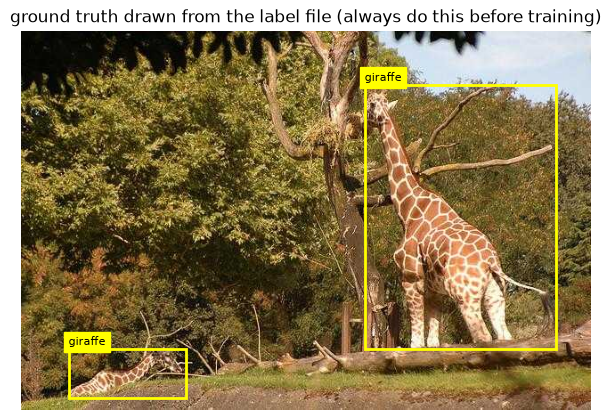

In [22]:
coco_names = YOLO(WEIGHTS["yolo26n.pt"]).names
COCO8_YAML = OUTPUT_DIR / "coco8.yaml"
COCO8_YAML.write_text(f"path: {rel(COCO8)}\ntrain: images/train\nval: images/val\nnames:\n"
                      + "".join(f"  {i}: {n}\n" for i, n in coco_names.items()))
print("".join(COCO8_YAML.read_text().splitlines(keepends=True)[:6]) + "  ... (80 names)\n")

coco8_img = sorted((COCO8 / "images" / "train").glob("*.jpg"))[1]
print(f"{rel(coco8_img)} → {rel(label_path_for(coco8_img))}:")
print(label_path_for(coco8_img).read_text())

image = cv2.imread(str(coco8_img))
gt_boxes, gt_cls = load_labels(coco8_img, image.shape[1], image.shape[0])
fig, ax = plt.subplots(figsize=(6, 4.5))
ax.imshow(image[..., ::-1])
for (x1, y1, x2, y2), c in zip(gt_boxes, gt_cls):
    ax.add_patch(Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=2, color="yellow"))
    ax.text(x1, y1 - 4, coco_names[int(c)], color="black", backgroundcolor="yellow", fontsize=8)
ax.set_title("ground truth drawn from the label file (always do this before training)")
ax.axis("off")
plt.tight_layout()
plt.show()

Now the dataset we will fine-tune on: **African Wildlife** (Ultralytics, 4 classes). A quick audit — images, instances per class, background images, and whether every label is valid:

In [23]:
WILDLIFE_YAML = OUTPUT_DIR / "african-wildlife.yaml"
WILDLIFE_YAML.write_text(f"path: {rel(WILDLIFE)}\ntrain: images/train\nval: images/val\ntest: images/test\nnames:\n"
                         + "".join(f"  {i}: {n}\n" for i, n in WILDLIFE_NAMES.items()))

audit_rows, bad_lines = [], 0
split_labels = {}
for split in ["train", "val", "test"]:
    images = sorted((WILDLIFE / "images" / split).glob("*.jpg"))
    labels = [np.loadtxt(label_path_for(p), ndmin=2) if label_path_for(p).exists() and label_path_for(p).stat().st_size
              else np.zeros((0, 5)) for p in images]
    split_labels[split] = dict(zip(images, labels))
    all_lab = np.concatenate(labels)
    bad_lines += int(((all_lab[:, 1:] < 0) | (all_lab[:, 1:] > 1)).any(axis=1).sum() + (all_lab[:, 0] >= len(WILDLIFE_NAMES)).sum())
    counts = np.bincount(all_lab[:, 0].astype(int), minlength=4)
    audit_rows.append({"split": split, "images": len(images), "background images": sum(len(l) == 0 for l in labels),
                       **{WILDLIFE_NAMES[i]: int(counts[i]) for i in range(4)}})
print(pd.DataFrame(audit_rows).set_index("split"))
print(f"\ninvalid label lines (coordinates outside 0..1 or unknown class id): {bad_lines}")

_two_zebra_ref = sum(int((lab[:, 0] == 3).sum() >= 2) for lab in split_labels["test"].values())

       images  background images  buffalo  elephant  rhino  zebra
split                                                            
train    1049                  0      398       557    398    575
val       225                  0       89        91     85    114
test      227                  0       66        99     75    135

invalid label lines (coordinates outside 0..1 or unknown class id): 0


### ✍️ Your Turn

`split_labels["test"]` maps each test image path to its label array (`class cx cy w h` rows). How many **test images contain at least two zebras** (class 3)?

In [24]:
n_images_two_zebras = None  # TODO: your code here
check("n_images_two_zebras", n_images_two_zebras, _two_zebra_ref,
      hint="Loop over split_labels['test'].values() and count arrays where (lab[:, 0] == 3).sum() >= 2.")

⏳ n_images_two_zebras: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_images_two_zebras = sum(int((lab[:, 0] == 3).sum() >= 2) for lab in split_labels["test"].values())
check("n_images_two_zebras", n_images_two_zebras, _two_zebra_ref)
```
</details>

> 💡 **Interview angle:** "You receive 10,000 labelled images from a vendor — what do you check before training?" — label format and normalization (draw samples), class-id mapping vs `names`, class balance per split, duplicate or near-duplicate images across splits (leakage), empty/background images, and tiny or degenerate boxes.

## 11. Augmentations and Their Real Argument Names 🟡

Detectors are data-hungry, so Ultralytics applies strong **training-time** augmentations. The arguments are passed to `model.train(...)`:

In [25]:
from ultralytics.cfg import get_cfg
from ultralytics.data import build_yolo_dataset
from ultralytics.data.utils import check_det_dataset

aug_help = {
    "mosaic": "probability of stitching 4 training images into one (more objects and scales per sample)",
    "close_mosaic": "turn mosaic off for the final N epochs, so the model finishes on natural-looking images",
    "mixup": "probability of blending two images and their labels",
    "cutmix": "probability of pasting a patch of one image (with its boxes) into another",
    "copy_paste": "copy object instances between images (segmentation / OBB datasets)",
    "hsv_h": "random hue shift (fraction)", "hsv_s": "random saturation change (fraction)", "hsv_v": "random brightness change (fraction)",
    "degrees": "random rotation (±degrees)", "translate": "random shift (± fraction of image size)",
    "scale": "random zoom (± gain)", "shear": "random shear (± degrees)", "perspective": "random perspective warp",
    "flipud": "probability of an up-down flip", "fliplr": "probability of a left-right flip", "bgr": "probability of swapping RGB↔BGR channels",
}
defaults = get_cfg()
print(pd.DataFrame({"default": [getattr(defaults, k) for k in aug_help], "what it does": list(aug_help.values())},
                   index=list(aug_help)).to_string())
print(f"\n'augment' is something else: {defaults.augment!r} by default — it switches on TEST-TIME augmentation in predict/val.")

              default                                                                              what it does
mosaic          1.000  probability of stitching 4 training images into one (more objects and scales per sample)
close_mosaic   10.000   turn mosaic off for the final N epochs, so the model finishes on natural-looking images
mixup           0.000                                       probability of blending two images and their labels
cutmix          0.000                 probability of pasting a patch of one image (with its boxes) into another
copy_paste      0.000                        copy object instances between images (segmentation / OBB datasets)
hsv_h           0.015                                                               random hue shift (fraction)
hsv_s           0.700                                                       random saturation change (fraction)
hsv_v           0.400                                                       random brightness change (fr

Let's look at what the network actually sees. We build the real Ultralytics training dataset for African Wildlife twice — with `mosaic=1.0` and `mosaic=0.0` — and draw the (augmented) boxes it returns.

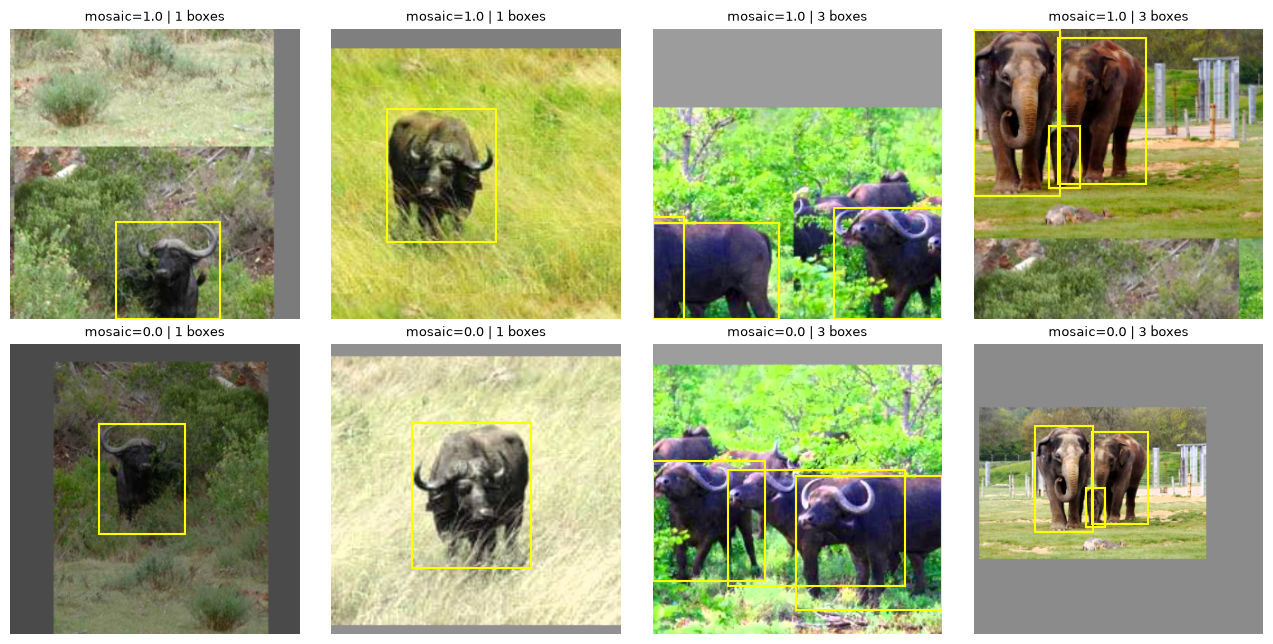

In [26]:
wildlife_data = check_det_dataset(str(WILDLIFE_YAML))
fig, axes = plt.subplots(2, 4, figsize=(13, 6.5))
for row, mosaic in enumerate([1.0, 0.0]):
    random.seed(1)
    aug_ds = build_yolo_dataset(get_cfg(overrides=dict(imgsz=320, mosaic=mosaic)), wildlife_data["train"], batch=4,
                                data=wildlife_data, mode="train")
    for col in range(4):
        item = aug_ds[col * 97]
        img = item["img"].permute(1, 2, 0).numpy()                   # CHW → HWC, already RGB
        ax = axes[row, col]
        ax.imshow(img)
        for (cx, cy, w, h), c in zip(item["bboxes"].numpy() * 320, item["cls"].numpy().ravel()):
            ax.add_patch(Rectangle((cx - w / 2, cy - h / 2), w, h, fill=False, lw=1.5, color="yellow"))
        ax.set_title(f"mosaic={mosaic} | {len(item['cls'])} boxes", fontsize=9)
        ax.axis("off")
plt.tight_layout()
plt.show()
del aug_ds

**Test-time augmentation (TTA)** is a different thing: `predict(..., augment=True)` runs the image at several scales and flips and merges the results. Measured on CPU:

In [27]:
tta_model = YOLO(WEIGHTS["yolo11n.pt"])
tta_rows = []
for augment in [False, True]:
    tta_model.predict(BUS, device="cpu", verbose=False, augment=augment)                  # warm-up
    runs = [tta_model.predict(BUS, device="cpu", verbose=False, augment=augment)[0] for _ in range(3)]
    tta_rows.append({"augment": augment, "boxes": len(runs[-1].boxes),
                     "inference ms (median)": float(np.median([r.speed["inference"] for r in runs]))})
tta_table = pd.DataFrame(tta_rows).set_index("augment").round(1)
print(tta_table)
print(f"→ TTA costs {tta_table.iloc[1, 1] / tta_table.iloc[0, 1]:.1f}× the inference time on this image")
del tta_model

         boxes  inference ms (median)
augment                              
False        5                   28.9
True         6                   74.4
→ TTA costs 2.6× the inference time on this image


> 💡 **Interview angle:** "Does `model.train(augment=True)` turn on mosaic?" — no. Mosaic is on by default through `mosaic=1.0` (and switched off for the last `close_mosaic` epochs). `augment` is the **test-time** augmentation flag for predict/val, which trades ~2× latency for a small accuracy gain.

## 12. Fine-Tuning on a Small Real Dataset 🟡

**Fine-tuning** starts from COCO-pretrained weights and continues training on your dataset. The backbone already knows edges, textures and animal shapes; the head learns your classes. Ultralytics even copies class rows whose names match (`elephant`, `zebra`) from the COCO head (`cls_remap=True`).

**Choices for a laptop-sized run (and why):**

| Setting | Value | Why |
|---|---|---|
| training images | a **random** half of `train` (~525 images), listed in a `.txt` file | the `fraction=` argument takes the *first* N files in sorted order — see Pitfall 1 |
| `epochs` | 6 | enough to show real learning in ~1.5 minutes; real projects use 50–300 |
| `imgsz`, `batch`, `workers`, `cache` | 320, 8, 0, False | animals are large in these photos; keeps memory < 2 GB |
| `optimizer` | `"auto"` (default) | picks **AdamW** with a small learning rate for short runs (< 10k iterations) and **MuSGD** for long ones — and *ignores* `lr0`. `lr0=0.01` is an SGD-style value; never pair it with Adam by hand. |
| `warmup_epochs` | 1 | the default of 3 would be half of this short run |
| `deterministic` | False | the MPS backend has no deterministic kernel for one training op and would warn |
| validation | the `val` split each epoch | the **test** split is not touched until the mini project |

In [28]:
EPOCHS, IMGSZ, BATCH = 6, 320, 8
train_images = sorted((WILDLIFE / "images" / "train").glob("*.jpg"))
subset = sorted(rng.permutation(len(train_images))[: len(train_images) // 2])
(WILDLIFE / "train_subset.txt").write_text("".join(f"./images/train/{train_images[i].name}\n" for i in subset))
FINETUNE_YAML = OUTPUT_DIR / "african-wildlife-subset.yaml"
FINETUNE_YAML.write_text(WILDLIFE_YAML.read_text().replace("train: images/train", "train: train_subset.txt"))

subset_counts = np.bincount(np.concatenate([split_labels["train"][train_images[i]][:, 0] for i in subset]).astype(int), minlength=4)
print(f"training on {len(subset)} random train images | instances per class: "
      f"{dict(zip(WILDLIFE_NAMES.values(), subset_counts.tolist()))}")

finetune_model = YOLO(WEIGHTS["yolo26n.pt"])
start = time.perf_counter()
finetune_model.train(data=str(FINETUNE_YAML), epochs=EPOCHS, imgsz=IMGSZ, batch=BATCH, workers=0, cache=False,
                     device=DEVICE, warmup_epochs=1, deterministic=False, seed=0, plots=False, verbose=False,
                     project=str(RUNS_DIR.resolve()), name="wildlife_finetune", exist_ok=True)
train_seconds = time.perf_counter() - start
RUN_DIR = Path(finetune_model.trainer.save_dir)
FINETUNED_WEIGHTS = RUN_DIR / "weights" / "best.pt"
optimizer_used = type(finetune_model.trainer.optimizer).__name__
print(f"trained {EPOCHS} epochs in {train_seconds:.0f} s on {DEVICE} | optimizer: {optimizer_used} | "
      f"lr0 argument {finetune_model.trainer.args.lr0} was ignored by optimizer='auto'")
print(f"run folder: {rel(RUN_DIR)} → {sorted(p.name for p in RUN_DIR.iterdir())}")
del finetune_model
free_memory()

training on 524 random train images | instances per class: {'buffalo': 195, 'elephant': 288, 'rhino': 227, 'zebra': 242}


trained 6 epochs in 75 s on mps | optimizer: AdamW | lr0 argument 0.01 was ignored by optimizer='auto'
run folder: _outputs/yolo/runs/wildlife_finetune → ['args.yaml', 'results.csv', 'weights']


 epoch    time  train/box_loss  train/cls_loss  train/l1_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/l1_loss  lr/pg0  lr/pg1  lr/pg2
     1 11.8819          1.0349          4.3064         0.0159                0.4123             0.5664            0.2578               0.1778        0.7856        4.2844       0.0169  0.0012  0.0012  0.0012
     2 24.3692          1.1289          3.3057         0.0181                0.5032             0.6457            0.5904               0.3957        1.0317        3.4367       0.0246  0.0010  0.0010  0.0010
     3 35.0271          1.1685          2.5217         0.0181                0.5344             0.6822            0.6510               0.4193        1.0172        2.6034       0.0234  0.0008  0.0008  0.0008
     4 45.7290          1.0890          2.1867         0.0167                0.7353             0.7242            0.7882               0.5803        0.9245        2.0902   

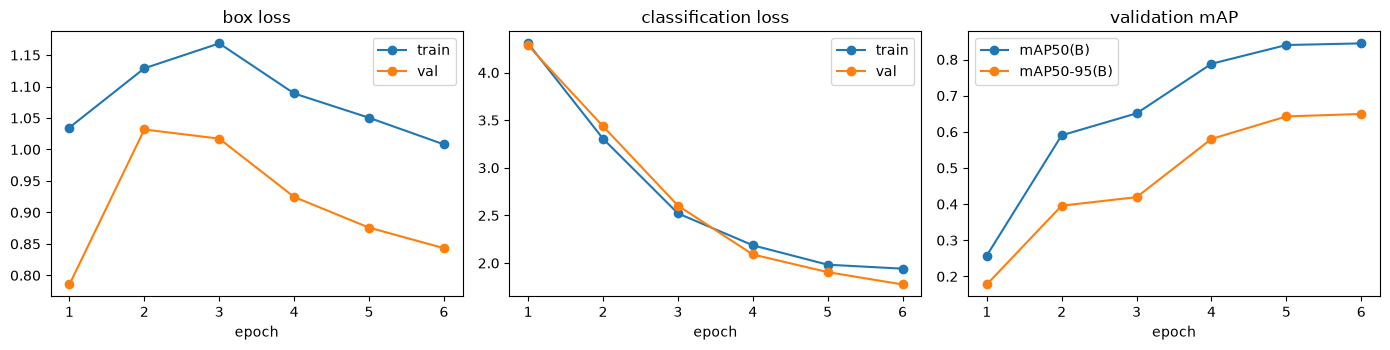

In [29]:
history = pd.read_csv(RUN_DIR / "results.csv")
print(history.round(4).to_string(index=False))
print(f"\nlearning rate after warm-up (epoch 1): {history['lr/pg0'].iloc[0]:.6f} "
      f"| Ultralytics' auto formula 0.002·5/(4+nc) with nc=4 = {0.002 * 5 / (4 + 4):.6f}")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6))
for col, label in [("train/box_loss", "train"), ("val/box_loss", "val")]:
    axes[0].plot(history["epoch"], history[col], marker="o", label=label)
for col, label in [("train/cls_loss", "train"), ("val/cls_loss", "val")]:
    axes[1].plot(history["epoch"], history[col], marker="o", label=label)
for col in ["metrics/mAP50(B)", "metrics/mAP50-95(B)"]:
    axes[2].plot(history["epoch"], history[col], marker="o", label=col.split("/")[1])
for ax, title in zip(axes, ["box loss", "classification loss", "validation mAP"]):
    ax.set(title=title, xlabel="epoch")
    ax.legend()
plt.tight_layout()
plt.show()

These are the real curves from the run above (`results.csv` is written by the trainer every epoch). Now the per-class validation metrics of the best checkpoint:

In [30]:
finetuned = YOLO(FINETUNED_WEIGHTS)
val_metrics = finetuned.val(data=str(FINETUNE_YAML), split="val", imgsz=IMGSZ, batch=BATCH, device=EVAL_DEVICE,
                            plots=False, verbose=False, project=str(RUNS_DIR.resolve()), name="wildlife_val", exist_ok=True)
print(pd.DataFrame({"AP@0.5": val_metrics.box.ap50, "AP@0.5:0.95": val_metrics.box.ap},
                   index=[WILDLIFE_NAMES[int(i)] for i in val_metrics.box.ap_class_index]).round(3))
print(f"\nvalidation mAP@0.5 = {val_metrics.box.map50:.3f} | mAP@0.5:0.95 = {val_metrics.box.map:.3f} | "
      f"speed per image (ms): {({k: round(v, 1) for k, v in val_metrics.speed.items()})}")
_best_epoch_ref = int(history.loc[history["metrics/mAP50-95(B)"].idxmax(), "epoch"])

          AP@0.5  AP@0.5:0.95
buffalo    0.786        0.633
elephant   0.774        0.569
rhino      0.905        0.731
zebra      0.903        0.662

validation mAP@0.5 = 0.842 | mAP@0.5:0.95 = 0.649 | speed per image (ms): {'preprocess': 0.0, 'inference': 5.0, 'loss': 0.0, 'postprocess': 0.1}


`best.pt` is the checkpoint with the highest **fitness** (in 8.4 that is mAP@0.5:0.95 on the validation split); `last.pt` is the final epoch.

### ✍️ Your Turn

Using the `history` DataFrame, which epoch had the highest validation **mAP@0.5:0.95** (column `metrics/mAP50-95(B)`)? Store the epoch number as an int.

In [31]:
best_epoch = None  # TODO: your code here
check("best_epoch", best_epoch, _best_epoch_ref, hint="history.loc[history['metrics/mAP50-95(B)'].idxmax(), 'epoch']")

⏳ best_epoch: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
best_epoch = int(history.loc[history["metrics/mAP50-95(B)"].idxmax(), "epoch"])
check("best_epoch", best_epoch, _best_epoch_ref)
```

With only 6 epochs the best epoch is usually one of the last ones — a sign that more epochs would still help.
</details>

> 💡 **Interview angle:** "How would you fine-tune a detector on 500 images?" — start from pretrained weights, keep strong augmentation, use a validation split for early stopping (`patience`) and model selection, check per-class AP and confusion, add background images if false positives appear, and only then consider freezing layers (`freeze=10`) or a larger model.

## 13. Multi-Object Tracking and Line Counting 🟡

A detector treats every frame independently. A **tracker** links detections over time and gives each object a persistent **ID** — needed for counting ("how many people crossed the door?"), speed estimation and behaviour analysis. Most trackers follow **tracking-by-detection**:

```
for each frame:
    detections = detector(frame)
    predict where every existing track should be now      (Kalman filter: constant-velocity motion model)
    cost[i, j] = 1 − IoU(track_i, detection_j)             (optionally + appearance / ReID distance)
    match with the Hungarian algorithm                       (minimum total cost, one-to-one)
    update matched tracks · start new tracks · delete tracks unseen for too long
```

| Tracker (Ultralytics `tracker=`) | Key idea |
|---|---|
| **ByteTrack** (`bytetrack.yaml`) | also associates **low-confidence** detections in a second round, recovering partly occluded objects |
| **BoT-SORT** (`botsort.yaml`) | ByteTrack + **camera-motion compensation** + optional **ReID** appearance features |
| OC-SORT, Deep OC-SORT, FastTrack, TrackTrack | other association strategies; `tracktrack.yaml` is the default in ultralytics 8.4.150 |

The API is `model.track(source, tracker="bytetrack.yaml", persist=True, stream=True)`; each `Results.boxes.id` then holds the track IDs. Our video is OpenCV's `vtest.avi`: pedestrians filmed by a fixed camera.

In [32]:
cap = cv2.VideoCapture(str(VIDEO))
VIDEO_FPS = cap.get(cv2.CAP_PROP_FPS)
N_FRAMES = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
FRAME_W, FRAME_H = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
ok, first_frame = cap.read()
cap.release()
LINE_X = FRAME_W // 2                                                  # a virtual vertical counting line
print(f"{rel(VIDEO)}: {N_FRAMES} frames, {VIDEO_FPS:.0f} FPS ({N_FRAMES / VIDEO_FPS:.0f} s), {FRAME_W}×{FRAME_H}")

# Detection pass (streamed): keep only a small (N, 5) array per frame
video_model = YOLO(WEIGHTS["yolo26n.pt"])
frame_detections, frame_speeds = [], []
start = time.perf_counter()
for r in video_model.predict(str(VIDEO), stream=True, classes=[0], conf=0.25, imgsz=640, device=DEVICE, verbose=False):
    frame_detections.append(np.hstack([r.boxes.xyxy.cpu().numpy(), r.boxes.conf.cpu().numpy()[:, None]]))
    frame_speeds.append(r.speed)
detect_seconds = time.perf_counter() - start
del video_model
free_memory()
per_stage = {k: float(np.median([s[k] for s in frame_speeds[5:]])) for k in frame_speeds[0]}
print(f"detected people in {len(frame_detections)} frames in {detect_seconds:.1f} s → {len(frame_detections) / detect_seconds:.0f} FPS end-to-end "
      f"(median ms: {({k: round(v, 1) for k, v in per_stage.items()})}) | people per frame: "
      f"{np.mean([len(d) for d in frame_detections]):.1f}")

_outputs/yolo/video/vtest.avi: 795 frames, 10 FPS (80 s), 768×576


detected people in 795 frames in 6.9 s → 116 FPS end-to-end (median ms: {'preprocess': 0.5, 'inference': 4.1, 'postprocess': 1.6}) | people per frame: 5.9


**Ultralytics trackers.** They need the small `lap` package (a fast linear-assignment solver). The cell below runs ByteTrack when `lap` is installed and says so honestly when it isn't.

In [33]:
HAS_LAP = importlib.util.find_spec("lap") is not None
tracker_runs = {}


def run_ultralytics_tracker(tracker_yaml):
    """Track people through the video with model.track (streamed) → {track_id: [(frame, foot_x, foot_y), ...]}, FPS."""
    track_model = YOLO(WEIGHTS["yolo26n.pt"])
    trajectories, n_frames = defaultdict(list), 0
    t0 = time.perf_counter()
    for r in track_model.track(str(VIDEO), stream=True, tracker=tracker_yaml, classes=[0], conf=0.25, imgsz=640,
                               device=DEVICE, verbose=False):
        if r.boxes.is_track:
            for tid, (x1, y1, x2, y2) in zip(r.boxes.id.int().tolist(), r.boxes.xyxy.cpu().numpy()):
                trajectories[tid].append((n_frames, (x1 + x2) / 2, y2))
        n_frames += 1
    fps = n_frames / (time.perf_counter() - t0)
    del track_model
    free_memory()
    return dict(trajectories=dict(trajectories), fps=fps)


if HAS_LAP:
    tracker_runs["ByteTrack (model.track)"] = run_ultralytics_tracker("bytetrack.yaml")
    bt = tracker_runs["ByteTrack (model.track)"]
    print(f"ByteTrack: {len(bt['trajectories'])} track IDs at {bt['fps']:.0f} FPS (detection + tracking)")
else:
    print("⏭️ Skipped model.track(): Ultralytics' trackers need the `lap` package, which is not installed in this "
          "environment. Install it with  pip install \"lap>=0.5.12\"  , restart the kernel and re-run. "
          "(We set YOLO_AUTOINSTALL=false, so Ultralytics won't install it silently.) The from-scratch tracker below runs either way.")

ByteTrack: 45 track IDs at 95 FPS (detection + tracking)


**The core idea in ~30 lines.** A minimal IoU tracker: Hungarian matching on IoU between each track's last box and the new detections, new IDs for unmatched detections, tracks deleted after `max_age` missed frames. It has **no motion model** (no Kalman filter) and no appearance features, so it is weaker than ByteTrack when people cross or are occluded — but it runs on the real detections from the video.

In [34]:
class IoUTracker:
    def __init__(self, iou_threshold=0.3, max_age=10, min_hits=3):
        self.iou_threshold, self.max_age, self.min_hits = iou_threshold, max_age, min_hits
        self.tracks = {}                                               # id → {"box", "last_seen", "hits"}
        self.next_id = 1

    def update(self, frame_idx, detections):
        """detections: (N, 5) array of x1, y1, x2, y2, conf → list of (track_id, box) confirmed in this frame."""
        track_ids = list(self.tracks)
        assigned = {}
        if track_ids and len(detections):
            iou = tv_box_iou(torch.tensor(np.array([self.tracks[t]["box"] for t in track_ids])),
                             torch.tensor(detections[:, :4])).numpy()
            rows, cols = linear_sum_assignment(-iou)                   # maximise total IoU
            assigned = {c: track_ids[r] for r, c in zip(rows, cols) if iou[r, c] >= self.iou_threshold}
        confirmed = []
        for j, det in enumerate(detections):
            tid = assigned.get(j)
            if tid is None:                                            # unmatched detection → new track
                tid, self.next_id = self.next_id, self.next_id + 1
                self.tracks[tid] = {"hits": 0}
            self.tracks[tid].update(box=det[:4], last_seen=frame_idx, hits=self.tracks[tid]["hits"] + 1)
            if self.tracks[tid]["hits"] >= self.min_hits:              # only report tracks seen a few times (fewer false IDs)
                confirmed.append((tid, det[:4]))
        self.tracks = {t: v for t, v in self.tracks.items() if frame_idx - v["last_seen"] <= self.max_age}
        return confirmed


scratch_tracker = IoUTracker()
scratch_trajectories = defaultdict(list)
start = time.perf_counter()
for frame_idx, dets in enumerate(frame_detections):
    for tid, (x1, y1, x2, y2) in scratch_tracker.update(frame_idx, dets):
        scratch_trajectories[tid].append((frame_idx, (x1 + x2) / 2, y2))  # foot point = bottom-centre of the box
track_seconds = time.perf_counter() - start
tracker_runs["IoU tracker (from scratch)"] = dict(trajectories=dict(scratch_trajectories),
                                                  fps=len(frame_detections) / (detect_seconds + track_seconds))
print(f"from-scratch tracker: {len(scratch_trajectories)} confirmed IDs | association took {track_seconds * 1000:.0f} ms "
      f"for {len(frame_detections)} frames")

from-scratch tracker: 94 confirmed IDs | association took 29 ms for 795 frames


**Counting line crossings from track IDs.** A track crosses the vertical line when its foot point changes side. Using IDs (not raw detections) means each person is counted **once per direction**, even if they wobble near the line.

tracker                    ByteTrack (model.track)  IoU tracker (from scratch)
track IDs                                     45.0                        94.0
median length (frames)                        89.0                        25.0
IDs lasting ≥ 1 s                             36.0                        63.0
crossed → (left to right)                     13.0                        15.0
crossed ← (right to left)                     17.0                        14.0
FPS (detect + track)                          95.1                       115.2


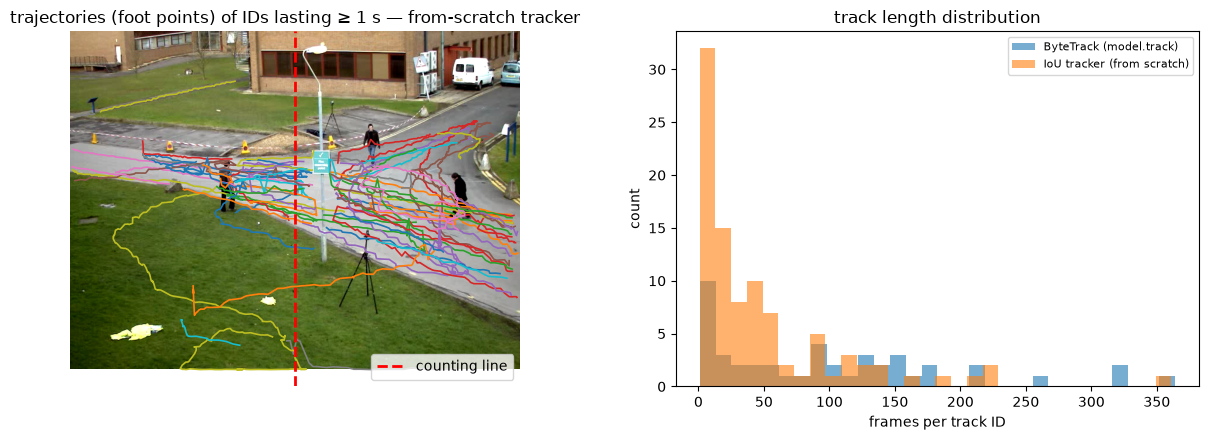

In [35]:
def count_line_crossings(trajectories, line_x):
    """Number of tracks that crossed a vertical line left→right and right→left (each track at most once per direction)."""
    left_to_right, right_to_left = set(), set()
    for tid, points in trajectories.items():
        side = np.sign(np.array([p[1] for p in points]) - line_x)
        side = side[side != 0]
        steps = np.diff(side)
        if (steps > 0).any():
            left_to_right.add(tid)
        if (steps < 0).any():
            right_to_left.add(tid)
    return len(left_to_right), len(right_to_left)


def track_summary(name, run):
    lengths = np.array([len(p) for p in run["trajectories"].values()])
    l2r, r2l = count_line_crossings(run["trajectories"], LINE_X)
    return {"tracker": name, "track IDs": len(lengths), "median length (frames)": float(np.median(lengths)),
            f"IDs lasting ≥ 1 s": int((lengths >= VIDEO_FPS).sum()), "crossed → (left to right)": l2r,
            "crossed ← (right to left)": r2l, "FPS (detect + track)": round(run["fps"], 1)}


print(pd.DataFrame([track_summary(n, r) for n, r in tracker_runs.items()]).set_index("tracker").T)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), gridspec_kw={"width_ratios": [1.4, 1]})
axes[0].imshow(first_frame[..., ::-1])
for tid, points in scratch_trajectories.items():
    pts = np.array(points)
    if len(pts) >= VIDEO_FPS:
        axes[0].plot(pts[:, 1], pts[:, 2], lw=1.2)
axes[0].axvline(LINE_X, color="red", ls="--", lw=2, label="counting line")
axes[0].set_title("trajectories (foot points) of IDs lasting ≥ 1 s — from-scratch tracker")
axes[0].legend(loc="lower right")
axes[0].axis("off")
for name, run in tracker_runs.items():
    axes[1].hist([len(p) for p in run["trajectories"].values()], bins=30, alpha=0.6, label=name)
axes[1].set(title="track length distribution", xlabel="frames per track ID", ylabel="count")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

_long_fraction_ref = float(np.mean([len(p) >= VIDEO_FPS for p in scratch_trajectories.values()]))

**Be careful with conclusions:** `vtest.avi` has no ground-truth tracks, so we can report *descriptive* statistics (IDs, lengths, crossings, FPS) but **not** tracking accuracy. More IDs than real people usually means **ID switches** (one person split into several IDs). Measuring that needs annotated video and metrics such as MOTA, IDF1 or HOTA. For production counting, Ultralytics also ships `solutions.ObjectCounter`, which wraps `model.track` + a counting region (it needs `lap` too).

### ✍️ Your Turn

What **fraction** of the from-scratch tracker's IDs (`scratch_trajectories`) last at least one second (`VIDEO_FPS` frames)? Short-lived IDs are often fragments caused by missed detections.

In [36]:
long_fraction = None  # TODO: your code here
check("long_fraction", long_fraction, _long_fraction_ref, hint="np.mean([len(p) >= VIDEO_FPS for p in scratch_trajectories.values()])")

⏳ long_fraction: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
long_fraction = float(np.mean([len(p) >= VIDEO_FPS for p in scratch_trajectories.values()]))
check("long_fraction", long_fraction, _long_fraction_ref)
```
</details>

> 💡 **Interview angle:** "Why does ByteTrack keep low-confidence detections?" — when a person is partly occluded, the detector's score drops below the normal threshold; matching those low-score boxes to *existing* tracks (but never starting new tracks from them) keeps the ID alive instead of breaking the track.

## 14. Export, Latency, and Deployment 🔴

`model.export(format=...)` converts the PyTorch model for a deployment runtime. Which formats you can produce depends on the extra packages installed:

In [37]:
from ultralytics.engine.exporter import export_formats

required_package = {"torchscript": "torch", "onnx": "onnx", "openvino": "openvino", "engine": "tensorrt", "coreml": "coremltools",
                    "saved_model": "tensorflow", "ncnn": "ncnn", "mnn": "MNN", "executorch": "executorch", "paddle": "paddle"}
formats = pd.DataFrame(export_formats())
formats = formats[formats["Argument"].isin(required_package)]
formats["needs package"] = formats["Argument"].map(required_package)
formats["installed here"] = formats["needs package"].map(lambda m: importlib.util.find_spec(m) is not None)
print(formats[["Format", "Argument", "CPU", "GPU", "needs package", "installed here"]].to_string(index=False))

               Format    Argument   CPU   GPU needs package  installed here
          TorchScript torchscript  True  True         torch            True
                 ONNX        onnx  True  True          onnx            True
             OpenVINO    openvino  True False      openvino           False
             TensorRT      engine False  True      tensorrt           False
               CoreML      coreml  True False   coremltools           False
TensorFlow SavedModel saved_model  True  True    tensorflow           False
         PaddlePaddle      paddle  True  True        paddle           False
                  MNN         mnn  True  True           MNN           False
                 NCNN        ncnn  True  True          ncnn           False
           ExecuTorch  executorch  True False    executorch           False


In [38]:
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    ts_path = Path(YOLO(WEIGHTS["yolo26n.pt"]).export(format="torchscript", imgsz=640))
print(f"TorchScript export → {rel(ts_path)} ({ts_path.stat().st_size / 1e6:.1f} MB)")
for category, message in sorted({(w.category.__name__, str(w.message).splitlines()[0][:110]) for w in caught}):
    print(f"  {category}: {message}")

if importlib.util.find_spec("onnx") and importlib.util.find_spec("onnxruntime"):
    onnx_path = Path(YOLO(WEIGHTS["yolo26n.pt"]).export(format="onnx", imgsz=640))
    print(f"ONNX export → {rel(onnx_path)} ({onnx_path.stat().st_size / 1e6:.1f} MB)")
else:
    onnx_path = None
    print("⏭️ Skipped ONNX export: needs the `onnx` and `onnxruntime` packages (pip install onnx onnxruntime). "
          "ONNX is the usual hand-off format for TensorRT, OpenVINO and ONNX Runtime.")

TorchScript export → _outputs/yolo/weights/yolo26n.torchscript (10.3 MB)


ONNX export → _outputs/yolo/weights/yolo26n.onnx (9.9 MB)


PyTorch 2.14 marks TorchScript (`torch.jit`) as deprecated, as the warning above says — we use it here only because it needs no extra package. New deployments should go through ONNX (→ ONNX Runtime / TensorRT / OpenVINO), CoreML on Apple devices, or `torch.export`-based ExecuTorch.

**Measured latency.** Median of 15 runs after warm-up on `bus.jpg` at 640 px, batch 1, on this laptop (other programs running can shift the numbers):

In [39]:
def benchmark(weights, device, runs=15, **kwargs):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FutureWarning)                # torch.jit.load deprecation (shown above)
        bench_model = YOLO(weights, task="detect")
        bench_model.predict(BUS, device=device, imgsz=640, verbose=False, **kwargs)    # warm-up
        speeds = [bench_model.predict(BUS, device=device, imgsz=640, verbose=False, **kwargs)[0].speed for _ in range(runs)]
    ms = {k: float(np.median([s[k] for s in speeds])) for k in speeds[0]}
    total = sum(ms.values())
    return {**{f"{k} ms": round(v, 2) for k, v in ms.items()}, "total ms": round(total, 2), "FPS (1000 / total)": round(1000 / total, 1)}


latency = {
    "YOLO11n .pt · CPU": benchmark(WEIGHTS["yolo11n.pt"], "cpu"),
    "YOLO26n .pt · CPU": benchmark(WEIGHTS["yolo26n.pt"], "cpu"),
    "YOLO26n .pt · CPU · nms=False": benchmark(WEIGHTS["yolo26n.pt"], "cpu", nms=False),
    "YOLO26n TorchScript · CPU": benchmark(ts_path, "cpu"),
}
if DEVICE != "cpu":
    latency[f"YOLO26n .pt · {DEVICE}"] = benchmark(WEIGHTS["yolo26n.pt"], DEVICE)
    latency[f"YOLO26n .pt · {DEVICE} · FP16"] = benchmark(WEIGHTS["yolo26n.pt"], DEVICE, quantize=16)
latency_table = pd.DataFrame(latency).T
print(latency_table)
fastest = latency_table["total ms"].idxmin()
print(f"\nfastest here: {fastest} at {latency_table.loc[fastest, 'total ms']:.1f} ms → {latency_table.loc[fastest, 'FPS (1000 / total)']:.0f} FPS")
if DEVICE != "cpu":
    fp32_ms, fp16_ms = latency_table.loc[f"YOLO26n .pt · {DEVICE}", "total ms"], latency_table.loc[f"YOLO26n .pt · {DEVICE} · FP16", "total ms"]
    print(f"FP16 vs FP32 on {DEVICE}: {fp32_ms / fp16_ms:.2f}× speed-up (values below 1 mean FP16 was slower)")
print(f"nms=False vs NMS on CPU: postprocess {latency_table.iloc[2, 2]:.2f} ms vs {latency_table.iloc[1, 2]:.2f} ms")
free_memory()

                               preprocess ms  inference ms  postprocess ms  total ms  FPS (1000 / total)
YOLO11n .pt · CPU                       0.52         21.25            0.34     22.10                45.2
YOLO26n .pt · CPU                       0.59         22.78            0.42     23.79                42.0
YOLO26n .pt · CPU · nms=False           0.63         22.88            0.09     23.60                42.4
YOLO26n TorchScript · CPU               0.61         25.99            0.39     26.99                37.1
YOLO26n .pt · mps                       0.42          3.59            1.01      5.02               199.1
YOLO26n .pt · mps · FP16                0.46          3.83            1.09      5.38               185.9

fastest here: YOLO26n .pt · mps at 5.0 ms → 199 FPS
FP16 vs FP32 on mps: 0.93× speed-up (values below 1 mean FP16 was slower)
nms=False vs NMS on CPU: postprocess 0.09 ms vs 0.42 ms


Things to notice in *your* table: a GPU speeds up the network itself, but pre- and post-processing still cost milliseconds; **FP16's benefit depends on the backend and model size** — for a 2.5 M-parameter nano model the gain is small and can even be negative, so measure it; and skipping NMS shrinks post-processing. Always benchmark on the target device.

**Deployment notes**
- **Edge GPUs (NVIDIA Jetson, servers):** export to **TensorRT** (`format="engine"`, FP16 or INT8). Engines are tied to the GPU model and TensorRT version — build them on the target machine.
- **CPUs / Intel:** OpenVINO or ONNX Runtime; **ARM boards / phones:** NCNN, LiteRT (TFLite), or CoreML on Apple devices.
- **Quantization:** post-training INT8 needs a **calibration set** of real images (`data=` during export) and must be re-validated — always compare mAP before and after; quantization-aware training (QAT) recovers accuracy when PTQ loses too much. DFL-free heads like YOLO26's are easier to quantize.
- **NMS placement:** NMS-based models either run NMS in Python after the runtime or embed it in the graph (`nms=True` on export); NMS-free heads avoid the question.
- **Throughput vs latency:** batching raises images/second on a server GPU but adds waiting time per image; a camera stream usually wants batch 1 and low latency.
- **RT-DETR / DETR:** transformer detectors are NMS-free and accurate, but heavier; on GPUs RT-DETR is competitive in real time, on small CPUs/NPUs a small YOLO is usually the practical choice.

> 💡 **Interview angle:** "Your model runs at 30 FPS in the notebook but 8 FPS on the device — what do you check?" — whether the benchmark included pre/post-processing, the input size and precision on the device, whether it's really using the accelerator (TensorRT/NPU), CPU-side NMS with a low `conf` (thousands of boxes), video decoding cost, and thermal throttling.

## 🔧 Build It From Scratch

Three things interviewers ask you to write on a whiteboard — each one checked against a trusted library.

### 1) Vectorized IoU for all pairs of boxes

For `N` boxes and `M` boxes we want an `N × M` IoU matrix without Python loops. Broadcasting does it: `a[:, None, :2]` has shape `(N, 1, 2)` and `b[None, :, :2]` has shape `(1, M, 2)`, so their element-wise max is `(N, M, 2)` — the top-left corner of every intersection at once.

In [40]:
def box_iou_matrix(a, b):
    """IoU between every box in a (N, 4) and every box in b (M, 4), xyxy format → (N, M)."""
    a, b = torch.as_tensor(a, dtype=torch.float64), torch.as_tensor(b, dtype=torch.float64)
    area_a = (a[:, 2] - a[:, 0]).clamp(min=0) * (a[:, 3] - a[:, 1]).clamp(min=0)
    area_b = (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
    top_left = torch.maximum(a[:, None, :2], b[None, :, :2])          # (N, M, 2)
    bottom_right = torch.minimum(a[:, None, 2:], b[None, :, 2:])      # (N, M, 2)
    intersection = (bottom_right - top_left).clamp(min=0).prod(dim=2)
    return intersection / (area_a[:, None] + area_b[None, :] - intersection).clamp(min=1e-12)


gen = torch.Generator().manual_seed(0)
corner = torch.rand(400, 2, generator=gen) * 500
random_boxes = torch.cat([corner, corner + torch.rand(400, 2, generator=gen) * 150 + 1], dim=1)

assert torch.allclose(box_iou_matrix(random_boxes[:200], random_boxes[200:]),
                      tv_box_iou(random_boxes[:200].double(), random_boxes[200:].double()), atol=1e-12)
assert torch.allclose(box_iou_matrix(cand_boxes, cand_boxes).float(), tv_box_iou(cand_boxes, cand_boxes), atol=1e-5)

start = time.perf_counter()
loop_iou = [[iou_pair(p.tolist(), q.tolist()) for q in random_boxes[200:]] for p in random_boxes[:200]]
loop_ms = (time.perf_counter() - start) * 1000
start = time.perf_counter()
vec_iou = box_iou_matrix(random_boxes[:200], random_boxes[200:])
vec_ms = (time.perf_counter() - start) * 1000
assert np.allclose(loop_iou, vec_iou.numpy())
print(f"✅ matches torchvision.ops.box_iou (random boxes and the real YOLO candidates) | "
      f"200×200 pairs: Python loop {loop_ms:.0f} ms vs vectorized {vec_ms:.2f} ms")

✅ matches torchvision.ops.box_iou (random boxes and the real YOLO candidates) | 200×200 pairs: Python loop 32 ms vs vectorized 0.63 ms


### 2) Greedy non-maximum suppression

Sort by score; take the best box; drop everything overlapping it by more than the threshold; repeat.

In [41]:
def nms_scratch(boxes, scores, iou_threshold):
    """Greedy NMS → indices of kept boxes, highest score first (same contract as torchvision.ops.nms)."""
    order = torch.argsort(scores, descending=True)
    keep = []
    while order.numel() > 0:
        best, order = order[0], order[1:]
        keep.append(int(best))
        if order.numel() > 0:
            overlap = box_iou_matrix(boxes[best][None], boxes[order])[0]
            order = order[overlap <= iou_threshold]                    # suppress boxes overlapping MORE than the threshold
    return torch.tensor(keep, dtype=torch.long)


random_scores = torch.rand(len(random_boxes), generator=gen)
for threshold in [0.3, 0.5, 0.7]:
    assert torch.equal(nms_scratch(random_boxes, random_scores, threshold), tv_nms(random_boxes, random_scores, threshold))
assert torch.equal(nms_scratch(cand_boxes, cand_scores, 0.7), tv_nms(cand_boxes, cand_scores, 0.7))

# class-aware: run NMS separately per class, then merge — compare with torchvision's batched_nms on the real candidates
per_class = torch.cat([torch.nonzero(cand_classes == c).flatten()[nms_scratch(cand_boxes[cand_classes == c], cand_scores[cand_classes == c], 0.7)]
                       for c in cand_classes.unique()])
per_class = per_class[torch.argsort(cand_scores[per_class], descending=True)]
assert torch.equal(per_class, tv_batched_nms(cand_boxes, cand_scores, cand_classes, 0.7))
print(f"✅ matches torchvision.ops.nms on {len(random_boxes)} random boxes (3 thresholds) and the {len(cand_boxes)} real candidates; "
      f"class-aware version matches batched_nms ({len(per_class)} boxes kept)")

✅ matches torchvision.ops.nms on 400 random boxes (3 thresholds) and the 47 real candidates; class-aware version matches batched_nms (5 boxes kept)


### 3) Average precision and mAP

Two parts:
1. **Matching** (per image, per IoU threshold) — COCO-style: go through predictions from most to least confident; each takes the unmatched same-class ground-truth box with the highest IoU ≥ threshold, if there is one → TP, otherwise FP.
2. **AP** (per class) — sort by confidence, cumulative TP/FP → precision and recall, make precision non-increasing from the right (the *envelope*), and take the area under it. To compare with Ultralytics exactly, we sample the envelope at 101 recall points and integrate with the trapezoid rule, which is what `ultralytics.utils.metrics.compute_ap` does (we read its source to check). pycocotools instead *averages* precision at 101 recall points — we implement that too and compare.

In [42]:
def match_greedy(pred_boxes, pred_scores, pred_cls, gt_boxes, gt_cls, iou_thresholds=IOU_THRESHOLDS):
    """COCO-style matching for ONE image → bool array (n_pred, n_thresholds): is each prediction a true positive?"""
    tp = np.zeros((len(pred_boxes), len(iou_thresholds)), dtype=bool)
    if len(pred_boxes) == 0 or len(gt_boxes) == 0:
        return tp
    iou = box_iou_matrix(pred_boxes, gt_boxes).numpy()
    iou[pred_cls[:, None] != gt_cls[None, :]] = 0.0                    # a prediction may only match its own class
    order = np.argsort(-pred_scores, kind="stable")
    for t, threshold in enumerate(iou_thresholds):
        gt_taken = np.zeros(len(gt_boxes), dtype=bool)
        for p in order:
            candidates = np.flatnonzero(~gt_taken & (iou[p] >= threshold))
            if len(candidates):
                g = candidates[np.argmax(iou[p, candidates])]
                gt_taken[g] = True
                tp[p, t] = True
    return tp


def _pr_curve(tp, scores, n_gt):
    order = np.argsort(-scores, kind="stable")
    hits = tp[order].astype(float)
    cum_tp, cum_fp = np.cumsum(hits), np.cumsum(1.0 - hits)
    return cum_tp / n_gt, cum_tp / (cum_tp + cum_fp)                   # recall, precision


def average_precision(tp, scores, n_gt):
    """Area under the precision envelope: 101-point interpolation + trapezoid rule (Ultralytics' method)."""
    if n_gt == 0 or len(tp) == 0:
        return 0.0
    recall, precision = _pr_curve(tp, scores, n_gt)
    r = np.concatenate([[0.0], recall, [recall[-1], 1.0]])
    p = np.concatenate([[1.0], precision, [0.0, 0.0]])
    envelope = np.maximum.accumulate(p[::-1])[::-1]
    grid = np.linspace(0, 1, 101)
    return float(np.trapezoid(np.interp(grid, r, envelope), grid))


def average_precision_coco(tp, scores, n_gt):
    """pycocotools-style: mean of the precision envelope sampled at 101 recall levels (0 where that recall is never reached)."""
    if n_gt == 0 or len(tp) == 0:
        return 0.0
    recall, precision = _pr_curve(tp, scores, n_gt)
    envelope = np.maximum.accumulate(precision[::-1])[::-1]
    idx = np.searchsorted(recall, np.linspace(0, 1, 101), side="left")
    return float(np.mean([envelope[i] if i < len(envelope) else 0.0 for i in idx]))


def evaluate_detections(records, classes, ap_fn=average_precision, iou_thresholds=IOU_THRESHOLDS):
    """→ ({class_id: AP at each IoU threshold}, pooled stats) for the given classes."""
    tps, scores, pred_cls, gt_cls = [], [], [], []
    for rec in records:
        kp, kg = np.isin(rec["pred_cls"], classes), np.isin(rec["gt_cls"], classes)
        tps.append(match_greedy(rec["pred_boxes"][kp], rec["pred_scores"][kp], rec["pred_cls"][kp],
                                rec["gt_boxes"][kg], rec["gt_cls"][kg], iou_thresholds))
        scores.append(rec["pred_scores"][kp])
        pred_cls.append(rec["pred_cls"][kp])
        gt_cls.append(rec["gt_cls"][kg])
    tp, score, pcls, gcls = (np.concatenate(x) for x in (tps, scores, pred_cls, gt_cls))
    order = np.argsort(-score)                                         # one global sort, like ap_per_class
    tp_s, score_s, pcls_s = tp[order], score[order], pcls[order]
    ap = {int(c): np.array([ap_fn(tp_s[pcls_s == c, t], score_s[pcls_s == c], int((gcls == c).sum()))
                            for t in range(len(iou_thresholds))]) for c in np.unique(gcls)}
    return ap, dict(tp=tp, conf=score, pred_cls=pcls, target_cls=gcls)


def mean_ap(ap):
    return float(np.mean([a[0] for a in ap.values()])), float(np.mean([a.mean() for a in ap.values()]))


scratch_ap, scratch_stats = evaluate_detections(zs_val, classes=[1, 3])

# Check 1 — AP integration: Ultralytics' ap_per_class on OUR true-positive matrix must give the same numbers
reference_ap = ultralytics_ap(scratch_stats)
for c in scratch_ap:
    assert np.allclose(scratch_ap[c], reference_ap[c], atol=1e-9), (c, scratch_ap[c], reference_ap[c])
print("✅ check 1: our AP equals ultralytics.utils.metrics.ap_per_class for every class and all 10 IoU thresholds")

# Check 2 — whole pipeline: our matching + AP vs Ultralytics' matching + AP on the same real predictions
agreement = (scratch_stats["tp"] == zs_stats["tp"]).mean()
ours_50, ours_5095 = mean_ap(scratch_ap)
ultra_50, ultra_5095 = mean_ap(zs_ap)
print(f"TP flags identical for {agreement:.2%} of (prediction, threshold) pairs — Ultralytics matches highest-IoU pairs first, COCO goes by confidence")
print(f"mAP@0.5     ours {ours_50:.4f} | Ultralytics {ultra_50:.4f}")
print(f"mAP@0.5:0.95 ours {ours_5095:.4f} | Ultralytics {ultra_5095:.4f}")
assert abs(ours_50 - ultra_50) < 0.01 and abs(ours_5095 - ultra_5095) < 0.01
print("✅ check 2: end-to-end mAP within 0.01 of Ultralytics")

coco_ap, _ = evaluate_detections(zs_val, classes=[1, 3], ap_fn=average_precision_coco)
print("\nsame predictions, two AP definitions:")
print(pd.DataFrame({"AP@0.5 trapezoid (Ultralytics)": {WILDLIFE_NAMES[c]: a[0] for c, a in scratch_ap.items()},
                    "AP@0.5 101-point mean (pycocotools)": {WILDLIFE_NAMES[c]: a[0] for c, a in coco_ap.items()}}).round(4))


def reference_ap50(preds, gts):
    """AP@0.5 for one class from (image, score, box) predictions and {image: [boxes]} ground truth — used by Exercise 6."""
    records = []
    for image_id in sorted(set(gts) | {p[0] for p in preds}):
        ps = [p for p in preds if p[0] == image_id]
        g = gts.get(image_id, [])
        records.append(dict(pred_boxes=np.array([p[2] for p in ps], dtype=float).reshape(-1, 4),
                            pred_scores=np.array([p[1] for p in ps], dtype=float), pred_cls=np.zeros(len(ps), dtype=int),
                            gt_boxes=np.array(g, dtype=float).reshape(-1, 4), gt_cls=np.zeros(len(g), dtype=int)))
    return float(evaluate_detections(records, classes=[0])[0][0][0])

✅ check 1: our AP equals ultralytics.utils.metrics.ap_per_class for every class and all 10 IoU thresholds
TP flags identical for 99.99% of (prediction, threshold) pairs — Ultralytics matches highest-IoU pairs first, COCO goes by confidence
mAP@0.5     ours 0.8613 | Ultralytics 0.8613
mAP@0.5:0.95 ours 0.7044 | Ultralytics 0.7043
✅ check 2: end-to-end mAP within 0.01 of Ultralytics

same predictions, two AP definitions:
          AP@0.5 trapezoid (Ultralytics)  AP@0.5 101-point mean (pycocotools)
elephant                          0.7838                               0.7822
zebra                             0.9387                               0.9343


## ⚠️ Common Pitfalls

### ❌ Pitfall 1 — `fraction=0.5` is not a random half of your data

Ultralytics' `fraction` keeps the **first** N image files in sorted order. In African Wildlife the file names start with the class number, so "half the data" silently means "almost only buffalo and elephants" — a model trained on it cannot learn rhinos. The fix is the random image list we used in Section 12.

In [43]:
half = len(train_images) // 2
first_half = np.bincount(np.concatenate([split_labels["train"][p][:, 0] for p in train_images[:half]]).astype(int), minlength=4)
print(f"file names: '{train_images[0].name}' … '{train_images[-1].name}'")
print("❌ fraction=0.5 (first half of the sorted list):", dict(zip(WILDLIFE_NAMES.values(), first_half.tolist())))
print("✅ random half (train_subset.txt)             :", dict(zip(WILDLIFE_NAMES.values(), subset_counts.tolist())))

file names: '1 (10).jpg' … '4 (99).jpg'
❌ fraction=0.5 (first half of the sorted list): {'buffalo': 392, 'elephant': 539, 'rhino': 0, 'zebra': 19}
✅ random half (train_subset.txt)             : {'buffalo': 195, 'elephant': 288, 'rhino': 227, 'zebra': 242}


### ❌ Pitfall 2 — Reading milliseconds as FPS

In [44]:
speed = results[0].speed                                               # the real bus.jpg measurement from Section 7
total_ms = sum(speed.values())
print(f"measured: {({k: round(v, 1) for k, v in speed.items()})}")
print(f"❌ 'inference is {speed['inference']:.0f}, so it runs at {speed['inference']:.0f} FPS'   (a number of ms is not a rate)")
print(f"❌ 'FPS = 1000 / inference = {1000 / speed['inference']:.0f}'                (ignores pre/post-processing)")
print(f"✅ FPS = 1000 / total = 1000 / {total_ms:.1f} ms = {1000 / total_ms:.1f} images per second (batch 1)")
print(f"   e.g. 80 ms per image → {1000 / 80:.1f} FPS, not 80 FPS")

measured: {'preprocess': 0.9, 'inference': 5.6, 'postprocess': 1.7}
❌ 'inference is 6, so it runs at 6 FPS'   (a number of ms is not a rate)
❌ 'FPS = 1000 / inference = 178'                (ignores pre/post-processing)
✅ FPS = 1000 / total = 1000 / 8.3 ms = 120.7 images per second (batch 1)
   e.g. 80 ms per image → 12.5 FPS, not 80 FPS


### ❌ Pitfall 3 — Feeding centre-format boxes into a corner-format IoU

In [45]:
gt_box = boxes_xyxy[:1]                                                # a real detected box (xyxy)
pred_box = gt_box + 5.0                                                # a prediction shifted by 5 px
print(f"❌ cxcywh passed as xyxy: IoU = {box_iou_matrix(xyxy_to_cxcywh(pred_box), xyxy_to_cxcywh(gt_box)).item():.3f}   (plausible-looking but wrong — no error raised)")
print(f"✅ both in xyxy         : IoU = {box_iou_matrix(pred_box, gt_box).item():.3f}")

❌ cxcywh passed as xyxy: IoU = 0.820   (plausible-looking but wrong — no error raised)
✅ both in xyxy         : IoU = 0.969


### ❌ Pitfall 4 — Computing mAP from predictions already filtered at the deployment threshold

mAP integrates the **whole** precision–recall curve. If you only keep boxes with `conf ≥ 0.25`, the low-confidence end of the curve disappears and recall can never reach its true maximum.

In [46]:
filtered_records = [{**r, "pred_boxes": r["pred_boxes"][r["pred_scores"] >= 0.25], "pred_cls": r["pred_cls"][r["pred_scores"] >= 0.25],
                     "pred_scores": r["pred_scores"][r["pred_scores"] >= 0.25]} for r in zs_val]
low_50, low_5095 = mean_ap(scratch_ap)
high_50, high_5095 = mean_ap(evaluate_detections(filtered_records, classes=[1, 3])[0])
print(f"❌ predictions with conf ≥ 0.25 : mAP@0.5 {high_50:.3f} | mAP@0.5:0.95 {high_5095:.3f}")
print(f"✅ predictions with conf ≥ 0.001: mAP@0.5 {low_50:.3f} | mAP@0.5:0.95 {low_5095:.3f}  (what model.val does)")

❌ predictions with conf ≥ 0.25 : mAP@0.5 0.822 | mAP@0.5:0.95 0.675
✅ predictions with conf ≥ 0.001: mAP@0.5 0.861 | mAP@0.5:0.95 0.704  (what model.val does)


### ❌ Pitfall 5 — Drawing letterboxed coordinates on the original image

The network saw a resized and padded 640×640 image (Section 4). Its boxes must be mapped back — subtract the padding, divide by the scale — before you draw or evaluate them on the original photo.

In [47]:
canvas_boxes = cand_boxes[kept].numpy()                                # boxes in letterboxed 640×640 coordinates
mapped_back = (canvas_boxes - np.array([lb_left, lb_top, lb_left, lb_top])) / lb_scale
reference_boxes = nms_model.predict(BUS, conf=0.25, device="cpu", verbose=False)[0].boxes.xyxy.cpu().numpy()
for label, boxes in [("❌ letterbox coordinates as-is", canvas_boxes), ("✅ padding removed, scale undone", mapped_back)]:
    best_iou = box_iou_matrix(boxes, reference_boxes).max(dim=1).values.mean().item()
    print(f"{label:34s}: mean best IoU with Ultralytics' boxes on the original image = {best_iou:.3f}")

❌ letterbox coordinates as-is     : mean best IoU with Ultralytics' boxes on the original image = 0.110
✅ padding removed, scale undone   : mean best IoU with Ultralytics' boxes on the original image = 0.971


## 🏋️ Practice Exercises

Try each one before opening the solution. Run the cell: ⏳ means not attempted, ✅ means correct.

### 🟢 Exercise 1 — From a label line to pixels
A YOLO label line reads `"0 0.5 0.5 0.25 0.5"` for a **640 × 480** image. Return the box as pixel **xyxy** `[x1, y1, x2, y2]`.

In [48]:
label_line = "0 0.5 0.5 0.25 0.5"
pixel_box = None  # TODO
check("pixel_box", pixel_box, [240, 120, 400, 360], hint="Multiply cx, w by 640 and cy, h by 480, then cxcywh_to_xyxy.")

⏳ pixel_box: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
label_line = "0 0.5 0.5 0.25 0.5"
cx, cy, w, h = map(float, label_line.split()[1:])
pixel_box = cxcywh_to_xyxy([cx * 640, cy * 480, w * 640, h * 480])
check("pixel_box", pixel_box, [240, 120, 400, 360])
```
</details>

### 🟢 Exercise 2 — Honest FPS
A benchmark reports `{"preprocess": 1.5, "inference": 22.0, "postprocess": 1.5}` (ms per image, batch 1). What is the throughput in images per second?

In [49]:
bench_speed = {"preprocess": 1.5, "inference": 22.0, "postprocess": 1.5}
fps = None  # TODO
check("fps", fps, 40.0, hint="1000 divided by the SUM of the three stages.")

⏳ fps: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
bench_speed = {"preprocess": 1.5, "inference": 22.0, "postprocess": 1.5}
fps = 1000 / sum(bench_speed.values())
check("fps", fps, 40.0)
```
</details>

### 🟢 Exercise 3 — How many predictions?
A YOLO head with strides 8, 16 and 32 receives a **480 × 480** image. How many locations does it predict at?

In [50]:
n_pred_480 = None  # TODO
check("n_pred_480", n_pred_480, 4725, hint="(480 // s) ** 2 summed over the three strides.")

⏳ n_pred_480: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
n_pred_480 = sum((480 // s) ** 2 for s in (8, 16, 32))
check("n_pred_480", n_pred_480, 4725)
```
60² + 30² + 15² = 3,600 + 900 + 225.
</details>

### 🟡 Exercise 4 — Class-aware NMS with one call
Implement class-aware NMS **without** `batched_nms`: shift every box by `class_id × (boxes.max() + 1)` so boxes of different classes can never overlap, then call `tv_nms` once. Return the kept indices as a list.

In [51]:
ex_boxes = torch.tensor([[0, 0, 10, 10], [1, 1, 11, 11], [0, 0, 10, 10], [20, 20, 30, 30]], dtype=torch.float32)
ex_scores = torch.tensor([0.9, 0.8, 0.7, 0.6])
ex_classes = torch.tensor([0, 0, 1, 1])
kept_batched = None  # TODO
check("kept_batched", kept_batched, tv_batched_nms(ex_boxes, ex_scores, ex_classes, 0.5).tolist(),
      hint="offsets = ex_classes.to(ex_boxes) * (ex_boxes.max() + 1); add offsets[:, None] to the boxes.")

⏳ kept_batched: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
ex_boxes = torch.tensor([[0, 0, 10, 10], [1, 1, 11, 11], [0, 0, 10, 10], [20, 20, 30, 30]], dtype=torch.float32)
ex_scores = torch.tensor([0.9, 0.8, 0.7, 0.6])
ex_classes = torch.tensor([0, 0, 1, 1])
offsets = ex_classes.to(ex_boxes) * (ex_boxes.max() + 1)
kept_batched = tv_nms(ex_boxes + offsets[:, None], ex_scores, 0.5).tolist()
check("kept_batched", kept_batched, tv_batched_nms(ex_boxes, ex_scores, ex_classes, 0.5).tolist())
```

Box 2 is identical to box 0 but belongs to class 1, so it survives; box 1 is suppressed by box 0.
</details>

### 🟡 Exercise 5 — Counting crossings of a horizontal line
`tracks_y` maps track IDs to the foot-point **y** coordinate in consecutive frames (y grows **downward** in images). Count how many tracks crossed `y = 100` going **down** at least once, and how many going **up** at least once. Return a tuple `(down, up)`.

In [52]:
tracks_y = {1: [80, 90, 105, 120], 2: [130, 110, 95], 3: [50, 60, 70], 4: [98, 102, 97, 103]}
crossings = None  # TODO
check("crossings", crossings, (2, 2), hint="Take np.sign(y - 100), drop zeros, and look at np.diff: +2 means down, -2 means up.")

⏳ crossings: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def count_horizontal_crossings(tracks, line_y):
    down, up = set(), set()
    for tid, ys in tracks.items():
        side = np.sign(np.array(ys) - line_y)
        steps = np.diff(side[side != 0])
        if (steps > 0).any():
            down.add(tid)
        if (steps < 0).any():
            up.add(tid)
    return len(down), len(up)


tracks_y = {1: [80, 90, 105, 120], 2: [130, 110, 95], 3: [50, 60, 70], 4: [98, 102, 97, 103]}
crossings = count_horizontal_crossings(tracks_y, 100)
check("crossings", crossings, (2, 2))
```

Track 4 jitters around the line and crosses three times, but is counted once per direction — which is why real counters use track IDs and often a small dead zone around the line.
</details>

### 🔴 Exercise 6 — AP@0.5 for one class (interview classic)
Given predictions as `(image_id, score, box)` and ground truth as `{image_id: [boxes]}`, compute **AP@0.5**. Write the matching yourself: go through predictions from highest to lowest score; each takes the not-yet-matched ground-truth box in its image with the highest IoU ≥ 0.5 (TP), otherwise it is an FP. Then call `average_precision(tp, scores, n_gt)` from the Build section for the area.

In [53]:
toy_gts = {"img1": [[0, 0, 10, 10], [20, 20, 30, 30]], "img2": [[5, 5, 15, 15]]}
toy_preds = [("img1", 0.9, [0, 0, 10, 10]), ("img1", 0.8, [21, 21, 31, 31]), ("img2", 0.7, [50, 50, 60, 60]),
             ("img1", 0.6, [0, 0, 9, 9]), ("img2", 0.5, [5, 5, 15, 16])]
ap50 = None  # TODO
check("ap50", ap50, reference_ap50(toy_preds, toy_gts), hint="Expected TP pattern by descending score: TP, TP, FP, FP (duplicate), TP; n_gt = 3.")

⏳ ap50: not attempted yet — replace None with your answer.


<details><summary>💡 Show solution</summary>

```python
def ap50_single_class(preds, gts, iou_threshold=0.5):
    taken = {image_id: np.zeros(len(boxes), dtype=bool) for image_id, boxes in gts.items()}
    ranked = sorted(preds, key=lambda p: -p[1])
    tp = np.zeros(len(ranked), dtype=bool)
    for k, (image_id, score, box) in enumerate(ranked):
        best, best_iou = None, iou_threshold
        for g, gt_box in enumerate(gts.get(image_id, [])):
            overlap = iou_pair(box, gt_box)
            if not taken[image_id][g] and overlap >= best_iou:
                best, best_iou = g, overlap
        if best is not None:
            taken[image_id][best] = True
            tp[k] = True
    n_gt = sum(len(boxes) for boxes in gts.values())
    return average_precision(tp, np.array([p[1] for p in ranked]), n_gt)


toy_gts = {"img1": [[0, 0, 10, 10], [20, 20, 30, 30]], "img2": [[5, 5, 15, 15]]}
toy_preds = [("img1", 0.9, [0, 0, 10, 10]), ("img1", 0.8, [21, 21, 31, 31]), ("img2", 0.7, [50, 50, 60, 60]),
             ("img1", 0.6, [0, 0, 9, 9]), ("img2", 0.5, [5, 5, 15, 16])]
ap50 = ap50_single_class(toy_preds, toy_gts)
check("ap50", ap50, reference_ap50(toy_preds, toy_gts))
```

Precision after each prediction: 1, 1, 0.67, 0.5, 0.6 with recall 0.33, 0.67, 0.67, 0.67, 1.0. The 0.6-score box is a **duplicate** of an already-matched object, so it is a false positive even though its IoU is 0.81 — that's the rule NMS failures get punished by.
</details>

## 🚀 Mini Project: Wildlife Detector and People Tracker, Honestly Evaluated

**Goal:** answer two practical questions with measured numbers only.
1. *Is fine-tuning worth it?* Compare the COCO-pretrained YOLO26n with our fine-tuned model on the **held-out test split** of African Wildlife.
2. *What does a detection + tracking pipeline deliver on a real video, and how fast is it on this laptop?*

**Evaluation protocol (no leakage):**
- Training used a random half of `train`; checkpoint selection used `val`; the confidence threshold study used `val`.
- The **227 test images are used only here, once**, with the same evaluator (our from-scratch mAP, verified against Ultralytics) for every model.
- The pretrained model only knows `elephant` and `zebra`, so we report two numbers: mAP over those two classes (fair to it) and mAP over all four classes (what the application needs).
- `vtest.avi` has no tracking ground truth, so for tracking we report descriptive statistics and speed — **not** accuracy.

### Step 1 — Pretrained (zero-shot) model on the test split

We evaluate at 320 px (the fine-tuned model's size) and at 640 px (the pretrained model's native size), so the pretrained model isn't handicapped.

In [54]:
test_images = sorted((WILDLIFE / "images" / "test").glob("*.jpg"))
start = time.perf_counter()
test_raw = {size: collect_predictions(pretrained, test_images, imgsz=size) for size in (320, 640)}
print(f"pretrained predictions on {len(test_images)} test images at 320 and 640 px: {time.perf_counter() - start:.1f} s")
pretrained_ap = {size: evaluate_detections(remap(test_raw[size], COCO_TO_WILDLIFE), classes=[1, 3])[0] for size in (320, 640)}
for size, ap in pretrained_ap.items():
    print(f"  @{size}: " + " | ".join(f"{WILDLIFE_NAMES[c]} AP@0.5 {a[0]:.3f}, AP@0.5:0.95 {a.mean():.3f}" for c, a in ap.items()))

pretrained predictions on 227 test images at 320 and 640 px: 8.9 s
  @320: elephant AP@0.5 0.795, AP@0.5:0.95 0.676 | zebra AP@0.5 0.977, AP@0.5:0.95 0.784
  @640: elephant AP@0.5 0.756, AP@0.5:0.95 0.644 | zebra AP@0.5 0.985, AP@0.5:0.95 0.826


What does the COCO model "see" when it looks at the two animals it was never taught? For each buffalo and rhino ground-truth box, we take the most-overlapping confident (≥ 0.25) prediction of **any** COCO class:

In [55]:
confusions = {0: Counter(), 2: Counter()}
for rec in test_raw[640]:
    confident = rec["pred_scores"] >= 0.25
    for gt_box, gt_c in zip(rec["gt_boxes"], rec["gt_cls"]):
        if gt_c not in confusions:
            continue
        label = "nothing (missed)"
        if confident.any():
            ious = box_iou_matrix(gt_box[None], rec["pred_boxes"][confident])[0].numpy()
            if ious.max() >= 0.5:
                label = pretrained.names[int(rec["pred_cls"][confident][ious.argmax()])]
        confusions[gt_c][label] += 1
for c, counts in confusions.items():
    print(f"{WILDLIFE_NAMES[c]:8s} ({sum(counts.values())} boxes) → pretrained model says: {counts.most_common(4)}")

buffalo  (66 boxes) → pretrained model says: [('cow', 39), ('elephant', 19), ('nothing (missed)', 5), ('dog', 1)]
rhino    (75 boxes) → pretrained model says: [('elephant', 43), ('cow', 23), ('sheep', 3), ('horse', 3)]


### Step 2 — Fine-tuned model on the test split

Same images, same evaluator, all four classes. As a cross-check we also run Ultralytics' own `val(split="test")`, which letterboxes images in batches and can differ slightly from per-image prediction.

In [56]:
start = time.perf_counter()
finetuned_test = collect_predictions(finetuned, test_images, imgsz=IMGSZ)
finetuned_ap, _ = evaluate_detections(finetuned_test, classes=[0, 1, 2, 3])
ft_50, ft_5095 = mean_ap(finetuned_ap)
test_metrics = finetuned.val(data=str(FINETUNE_YAML), split="test", imgsz=IMGSZ, batch=BATCH, device=EVAL_DEVICE, plots=False,
                             verbose=False, project=str(RUNS_DIR.resolve()), name="wildlife_test", exist_ok=True)
print(f"fine-tuned model on test ({time.perf_counter() - start:.1f} s):")
print(f"  our evaluator      : mAP@0.5 {ft_50:.3f} | mAP@0.5:0.95 {ft_5095:.3f}")
print(f"  Ultralytics val()  : mAP@0.5 {test_metrics.box.map50:.3f} | mAP@0.5:0.95 {test_metrics.box.map:.3f}")
print(f"  difference         : {abs(ft_50 - test_metrics.box.map50):.3f} / {abs(ft_5095 - test_metrics.box.map):.3f}")

fine-tuned model on test (6.1 s):
  our evaluator      : mAP@0.5 0.902 | mAP@0.5:0.95 0.699
  Ultralytics val()  : mAP@0.5 0.878 | mAP@0.5:0.95 0.680
  difference         : 0.024 / 0.019


### Step 3 — Side-by-side comparison

          test GT boxes  AP50-95 pretrained@320  AP50-95 pretrained@640  AP50-95 fine-tuned@320
buffalo              66                   0.000                   0.000                   0.732
elephant             99                   0.676                   0.644                   0.679
rhino                75                   0.000                   0.000                   0.754
zebra               135                   0.784                   0.826                   0.633
(buffalo and rhino are 0.0 for the pretrained model by construction: those classes do not exist in COCO)

                mAP50-95 elephant+zebra  mAP50-95 all 4 classes
pretrained@320                    0.730                   0.365
pretrained@640                    0.735                   0.367
fine-tuned@320                    0.656                   0.699

On the classes COCO already knew, fine-tuned vs best pretrained (pretrained@640): -0.079 mAP@0.5:0.95 → the pretrained model is still better there — 6 short 

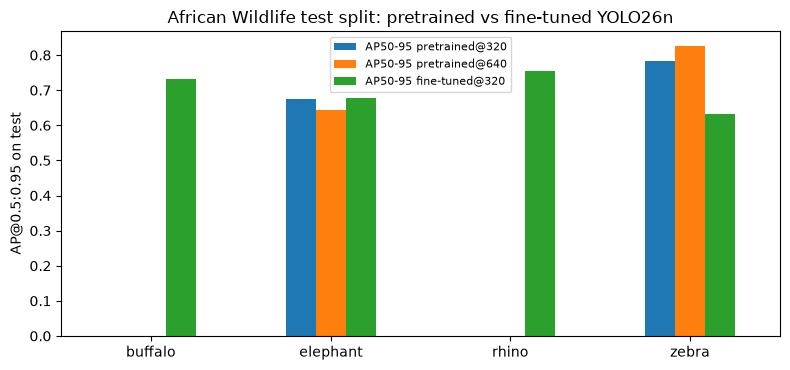

In [57]:
comparison = pd.DataFrame(index=[WILDLIFE_NAMES[c] for c in range(4)])
comparison["test GT boxes"] = [int(sum((r["gt_cls"] == c).sum() for r in finetuned_test)) for c in range(4)]
for label, ap in [("pretrained@320", pretrained_ap[320]), ("pretrained@640", pretrained_ap[640]), ("fine-tuned@320", finetuned_ap)]:
    comparison[f"AP50-95 {label}"] = [ap[c].mean() if c in ap else 0.0 for c in range(4)]
print(comparison.round(3))
print("(buffalo and rhino are 0.0 for the pretrained model by construction: those classes do not exist in COCO)\n")

known = ["elephant", "zebra"]
summary = pd.DataFrame({
    "mAP50-95 elephant+zebra": comparison.loc[known, [c for c in comparison.columns if c.startswith("AP50-95")]].mean(),
    "mAP50-95 all 4 classes": comparison[[c for c in comparison.columns if c.startswith("AP50-95")]].mean(),
})
summary.index = [i.replace("AP50-95 ", "") for i in summary.index]
print(summary.round(3))

best_pretrained = summary.loc[["pretrained@320", "pretrained@640"], "mAP50-95 elephant+zebra"].idxmax()
gap = summary.loc["fine-tuned@320", "mAP50-95 elephant+zebra"] - summary.loc[best_pretrained, "mAP50-95 elephant+zebra"]
print(f"\nOn the classes COCO already knew, fine-tuned vs best pretrained ({best_pretrained}): {gap:+.3f} mAP@0.5:0.95 → "
      + ("fine-tuning also improved them." if gap > 0 else
         "the pretrained model is still better there — 6 short epochs at 320 px did not beat COCO-scale training on those classes."))
print(f"On the full 4-class task: fine-tuned {summary.loc['fine-tuned@320', 'mAP50-95 all 4 classes']:.3f} vs best pretrained "
      f"{summary['mAP50-95 all 4 classes'].iloc[:2].max():.3f} — the pretrained model simply cannot output buffalo or rhino.")

fig, ax = plt.subplots(figsize=(8, 3.8))
comparison.drop(columns="test GT boxes").plot.bar(ax=ax, rot=0)
ax.set(ylabel="AP@0.5:0.95 on test", title="African Wildlife test split: pretrained vs fine-tuned YOLO26n")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Step 4 — Tracking report on the real video

Section 13 already ran detection on every frame and our from-scratch tracker (plus ByteTrack if `lap` is installed). If `lap` is available we add BoT-SORT for comparison.

In [58]:
if HAS_LAP:
    tracker_runs["BoT-SORT (model.track)"] = run_ultralytics_tracker("botsort.yaml")
else:
    print("⏭️ BoT-SORT comparison skipped: Ultralytics trackers need `lap` (see Section 13). Reporting the from-scratch tracker only.\n")

tracking_report = pd.DataFrame([track_summary(n, r) for n, r in tracker_runs.items()]).set_index("tracker")
print(tracking_report.T)
detection_fps = len(frame_detections) / detect_seconds
print(f"\ndetection alone: {detection_fps:.0f} FPS on {DEVICE} at 640 px vs the video's {VIDEO_FPS:.0f} FPS → "
      + ("fast enough for this stream in real time on this laptop." if detection_fps > VIDEO_FPS else "slower than real time on this laptop."))
print("Not measured: tracking accuracy (no ground-truth IDs) — more IDs than people usually indicates ID switches or fragments.")

tracker                    ByteTrack (model.track)  IoU tracker (from scratch)  BoT-SORT (model.track)
track IDs                                     45.0                        94.0                    41.0
median length (frames)                        89.0                        25.0                    95.0
IDs lasting ≥ 1 s                             36.0                        63.0                    34.0
crossed → (left to right)                     13.0                        15.0                    14.0
crossed ← (right to left)                     17.0                        14.0                    17.0
FPS (detect + track)                          95.1                       115.2                    45.3

detection alone: 116 FPS on mps at 640 px vs the video's 10 FPS → fast enough for this stream in real time on this laptop.
Not measured: tracking accuracy (no ground-truth IDs) — more IDs than people usually indicates ID switches or fragments.


### Step 5 — Results summary

In [59]:
report = {
    "training": f"{len(subset)} random train images, {EPOCHS} epochs, {IMGSZ} px, {optimizer_used}, {train_seconds:.0f} s on {DEVICE}",
    "fine-tuned test mAP@0.5 / @0.5:0.95 (ours)": f"{ft_50:.3f} / {ft_5095:.3f}",
    "fine-tuned test mAP@0.5 / @0.5:0.95 (Ultralytics val)": f"{test_metrics.box.map50:.3f} / {test_metrics.box.map:.3f}",
    "best pretrained, elephant+zebra only, mAP@0.5:0.95": f"{summary.loc[best_pretrained, 'mAP50-95 elephant+zebra']:.3f} ({best_pretrained})",
    "video": f"{len(frame_detections)} frames, detection {detection_fps:.0f} FPS on {DEVICE}",
}
for name, row in tracking_report.iterrows():
    report[f"tracking · {name}"] = (f"{row['track IDs']} IDs, median {row['median length (frames)']:.0f} frames, "
                                     f"{row['crossed → (left to right)']} → / {row['crossed ← (right to left)']} ← crossings, {row['FPS (detect + track)']} FPS")
for key, value in report.items():
    print(f"{key:55s} {value}")
free_memory()

training                                                524 random train images, 6 epochs, 320 px, AdamW, 75 s on mps
fine-tuned test mAP@0.5 / @0.5:0.95 (ours)              0.902 / 0.699
fine-tuned test mAP@0.5 / @0.5:0.95 (Ultralytics val)   0.878 / 0.680
best pretrained, elephant+zebra only, mAP@0.5:0.95      0.735 (pretrained@640)
video                                                   795 frames, detection 116 FPS on mps
tracking · ByteTrack (model.track)                      45.0 IDs, median 89 frames, 13.0 → / 17.0 ← crossings, 95.1 FPS
tracking · IoU tracker (from scratch)                   94.0 IDs, median 25 frames, 15.0 → / 14.0 ← crossings, 115.2 FPS
tracking · BoT-SORT (model.track)                       41.0 IDs, median 95 frames, 14.0 → / 17.0 ← crossings, 45.3 FPS


**Stretch goals**
1. Train longer (30–50 epochs) or at 640 px and plot test mAP vs training time — where do the returns diminish?
2. Freeze the backbone (`freeze=10`) and compare speed and mAP with full fine-tuning on the same budget.
3. Install `lap`, compare ByteTrack, BoT-SORT and TrackTrack, and annotate 100 frames of the video yourself to compute IDF1.
4. Add a dead zone of ±10 px around the counting line and see how the crossing counts change.
5. Install `onnx` + `onnxruntime`, export the fine-tuned model, and check that its test mAP is unchanged.

### 🗣️ How to talk about this in an interview
- "I fine-tuned a COCO-pretrained YOLO26n on a 4-class wildlife dataset on a laptop, selected the checkpoint on validation data and touched the test split once, with the same evaluator for every model."
- "I verified my own mAP implementation against Ultralytics' `ap_per_class` and reported both mAP@0.5 and mAP@0.5:0.95, plus a zero-shot baseline evaluated at two resolutions so the comparison was fair."
- "I caught a data bug: Ultralytics' `fraction` takes the first files in sorted order, and the file names were grouped by class, so a 50% 'subset' contained almost no rhinos or zebras. I switched to a random file list."
- "For the video, I built tracking-by-detection with Hungarian matching and counted line crossings per track ID; I reported FPS as 1000 / total milliseconds and was explicit that without ground-truth IDs I couldn't claim tracking accuracy."
- "Next I would train longer at higher resolution, quantify ID switches on an annotated clip, and export to ONNX/TensorRT with a before/after mAP check."

## 🎤 Interview Q&A

Try answering **out loud** before opening each answer.

### 🧠 Concepts

**Q1. What is IoU, and where is it used in an object detector?**

<details><summary>Show answer</summary>

- **30-second answer:** Intersection area divided by union area of two boxes, from 0 (no overlap) to 1 (identical). It decides whether a prediction matches a ground-truth box during evaluation, which duplicates NMS removes, and it appears in the box-regression loss.
- **Go deeper:** Plain IoU has zero gradient when boxes don't overlap, so losses use GIoU (enclosing-box penalty), DIoU (centre distance) or CIoU (+ aspect ratio); Ultralytics uses CIoU. IoU is scale-invariant but harsh on small objects: a 10-px shift drops a 20-px box to IoU 0.33.
- **❌ Common wrong answer:** "IoU is the intersection divided by the ground-truth area" — that's a different overlap measure (IoA), and it ignores false area in the prediction.

</details>

**Q2. Explain mAP@0.5 vs mAP@0.5:0.95. How is AP computed?**

<details><summary>Show answer</summary>

- **30-second answer:** For each class, sort predictions by confidence, mark each TP/FP by matching to unmatched ground truth at an IoU threshold, build the precision–recall curve, and take the area under its monotone envelope. mAP averages over classes; mAP@0.5 uses IoU 0.5, mAP@0.5:0.95 averages 10 thresholds from 0.5 to 0.95 and rewards precise localization (COCO's main metric).
- **Go deeper:** Interpolation differs by tool (VOC2007 11-point, COCO 101-point mean, Ultralytics 101-point trapezoid), so only compare numbers from the same evaluator. Evaluate with a very low confidence threshold so the whole curve is included.
- **❌ Common wrong answer:** "mAP is the average accuracy over images" or "mAP@0.5:0.95 means IoU between 0.5 and 0.95 counts as correct".

</details>

**Q3. How does non-maximum suppression work, and when does it fail?**

<details><summary>Show answer</summary>

- **30-second answer:** Filter by confidence, sort by score, keep the best box, delete remaining boxes of the same class whose IoU with it exceeds a threshold, repeat. It removes the duplicate boxes neighbouring grid cells predict for one object.
- **Go deeper:** It fails in crowds (real neighbours overlap and get suppressed) and adds a hand-tuned threshold and CPU post-processing time. Remedies: Soft-NMS (decay scores), class-agnostic vs class-aware choice, or NMS-free detectors (DETR's Hungarian matching, YOLOv10/YOLO26 one-to-one heads).
- **❌ Common wrong answer:** "NMS keeps the box with the highest IoU" — it keeps the highest *score* and uses IoU only to decide what to delete.

</details>

**Q4. Compare one-stage and two-stage detectors. What do RPN, RoI Align and FPN do?**

<details><summary>Show answer</summary>

- **30-second answer:** Two-stage detectors (Faster/Mask R-CNN) first propose regions with a Region Proposal Network, then crop features per region with RoI Align and classify/refine each; one-stage detectors (YOLO, RetinaNet) predict classes and boxes densely in a single pass. Two-stage was historically more accurate, one-stage is faster and simpler to deploy.
- **Go deeper:** FPN builds a multi-scale feature pyramid with a top-down path so small objects get semantically strong high-resolution features. RoI Align samples features with bilinear interpolation instead of RoI Pool's rounding, which matters for pixel-accurate masks in Mask R-CNN.
- **❌ Common wrong answer:** "One-stage detectors can't detect multiple objects" or "two-stage means two separate neural networks trained independently" (they're trained jointly).

</details>

**Q5. Anchor-based vs anchor-free heads — and does YOLOv8/YOLO11 predict objectness?**

<details><summary>Show answer</summary>

- **30-second answer:** Anchor-based heads predict offsets from preset box shapes at each location; anchor-free heads predict distances from each grid point to the four box sides. YOLOv8/YOLO11/YOLO26 are anchor-free with a decoupled head — a box branch and a class branch — and no objectness output.
- **Go deeper:** YOLO11 predicts each side distance as a distribution over 16 bins (Distribution Focal Loss) and uses its expectation; YOLO26 drops DFL (`reg_max=1`) for simpler export and quantization. Anchor-free removes anchor tuning per dataset and reduces the number of predictions.
- **❌ Common wrong answer:** "YOLOv8 multiplies objectness by class probability" — that was YOLOv3–v5.

</details>

**Q6. How can a detector work without NMS?**

<details><summary>Show answer</summary>

- **30-second answer:** Train with **one-to-one** assignment so exactly one prediction is responsible for each object: DETR uses Hungarian matching between a fixed set of queries and ground-truth boxes; YOLOv10 and YOLO26 add a one-to-one head (trained alongside a one-to-many head that gives richer supervision) whose top-k outputs need no NMS.
- **Go deeper:** Benefits: no IoU threshold to tune, deterministic latency, easier export to accelerators. In ultralytics 8.4 you choose the NMS-free head with `nms=False`; we measured that its output is independent of `iou`.
- **❌ Common wrong answer:** "They just set the NMS threshold to 1.0" — that would keep all duplicates.

</details>

**Q7. How do trackers like ByteTrack and BoT-SORT work, and how do you evaluate tracking?**

<details><summary>Show answer</summary>

- **30-second answer:** Tracking-by-detection: a Kalman filter predicts each track's box, detections are associated to tracks by IoU (plus appearance for ReID variants) using Hungarian matching, unmatched detections start tracks, stale tracks are deleted. ByteTrack also matches low-score detections in a second pass; BoT-SORT adds camera-motion compensation and optional ReID.
- **Go deeper:** Evaluate on annotated video with MOTA (misses, false positives, ID switches), IDF1 (identity consistency) and HOTA (balances detection and association). Without ground-truth IDs you can only report descriptive statistics.
- **❌ Common wrong answer:** "Match each box to the nearest box in the previous frame" — greedy nearest-neighbour breaks on crossings and occlusions.

</details>

### 💻 Coding

**Q8. Write IoU for all pairs between N and M boxes without loops.**

<details><summary>Show answer</summary>

- **30-second answer:** `tl = max(a[:, None, :2], b[None, :, :2]); br = min(a[:, None, 2:], b[None, :, 2:]); inter = clip(br - tl, 0).prod(-1); iou = inter / (area_a[:, None] + area_b[None, :] - inter)`.
- **Go deeper:** Clamp widths at 0 for non-overlapping boxes, guard the division, state the box format, and verify against `torchvision.ops.box_iou`. Memory is O(N·M) — chunk for huge sets.
- **❌ Common wrong answer:** Forgetting to clamp negative intersections (disjoint boxes get positive "intersection" when both width and height are negative).

</details>

**Q9. Implement NMS. How do you make it class-aware efficiently?**

<details><summary>Show answer</summary>

- **30-second answer:** `order = argsort(scores)[::-1]; while order: i = order[0]; keep i; order = order[1:][iou(box_i, boxes[order[1:]]) <= thr]`. For class-aware NMS in one call, offset boxes by `class_id × (max_coord + 1)` so different classes never overlap.
- **Go deeper:** Worst case O(n²); limit candidates by a confidence filter and a top-k before NMS (Ultralytics caps at `max_nms` candidates and `max_det` outputs). Use the vectorized IoU of one box vs the rest in each iteration.
- **❌ Common wrong answer:** Suppressing boxes with IoU *below* the threshold, or comparing each box only to its immediate neighbour in the sorted list.

</details>

**Q10. Given predictions and ground truth for many images, compute AP@0.5 for one class.**

<details><summary>Show answer</summary>

- **30-second answer:** Pool predictions across images and sort by score. For each, find the unmatched ground-truth box in its image with the highest IoU ≥ 0.5: TP (mark it matched) else FP. Cumulative TP/FP → precision and recall (divide by total GT count), make precision non-increasing from the right, integrate over recall.
- **Go deeper:** Duplicates of an already-matched object are FPs; images with no ground truth still contribute FPs; say which interpolation you use. This notebook's version matches Ultralytics' `ap_per_class` to 1e-9.
- **❌ Common wrong answer:** Dividing recall by the number of *predictions*, or allowing one ground-truth box to be matched by several predictions.

</details>

### 🐛 Debugging Scenarios

**Q11. Training loss goes down nicely, but validation mAP stays near 0. What do you check?**

<details><summary>Show answer</summary>

- **30-second answer:** Labels first: draw ground truth on images to check normalized centre-format coordinates, class-id mapping against `names`, and that val labels are found (the images→labels path rule). Then check the evaluation: correct split, image size, and whether validation uses the right class list.
- **Go deeper:** Other causes: pixel coordinates in label files (dropped as out-of-range), train/val class ids swapped between tools, a val set without labels, or evaluating a YAML-initialized model instead of the trained weights.
- **❌ Common wrong answer:** "Train for more epochs" or "lower the learning rate" before inspecting any labels.

</details>

**Q12. After a fine-tuning run on a subset, two of four classes have AP ≈ 0 while the others look fine. Why?**

<details><summary>Show answer</summary>

- **30-second answer:** Check the class distribution of the images actually used for training. A classic cause is subsetting by taking the *first* N files (Ultralytics' `fraction` does this) when file names are grouped by class — those classes were never trained on.
- **Go deeper:** Also check class imbalance, label ids for those classes, and whether they appear in the validation split. Fix with a random or stratified image list, then compare per-class AP.
- **❌ Common wrong answer:** "Those classes are just harder" — without looking at how many training instances they had.

</details>

**Q13. The detector scores well on validation but performs badly on the production camera. What could be wrong?**

<details><summary>Show answer</summary>

- **30-second answer:** A mismatch between training and serving: domain shift (lighting, viewpoint, resolution), different preprocessing (RGB vs BGR, missing letterbox or wrong scale-back of boxes), a different input size, or a confidence threshold that was tuned elsewhere.
- **Go deeper:** Log production frames and run the offline evaluator on a labelled sample; compare predictions from the exported model with the PyTorch model on identical inputs; add production-like images (including background frames) to training; monitor confidence distributions for drift.
- **❌ Common wrong answer:** "The model is overfitting to validation" without checking the serving pipeline.

</details>

### 🏗️ Design

**Q14. Design a system that counts people entering and leaving a store from 50 cameras in real time.**

<details><summary>Show answer</summary>

- **30-second answer:** Per camera: decode frames → small detector (e.g. YOLO nano/small exported to TensorRT or an edge NPU) → tracker (ByteTrack) → line/zone crossing per track ID with a dead zone → emit events (camera, time, direction) to a queue → aggregate in a database/dashboard. Batch frames across cameras on a GPU server, or run on-camera edge devices to save bandwidth.
- **Go deeper:** Budget latency and FPS per stream (people counting often works at 5–10 FPS), choose thresholds on labelled clips from these cameras, measure count error against manual counts and ID switches, handle camera outages, monitor drift, and address privacy (no face storage, on-device processing).
- **❌ Common wrong answer:** "Run the biggest model on every frame at full resolution and count detections per frame" — per-frame counts double-count the same person.

</details>

**Q15. Your objects are tiny (a few pixels) in 4K aerial images. How do you adapt a YOLO pipeline?**

<details><summary>Show answer</summary>

- **30-second answer:** Don't shrink 4K images to 640 px. Train and infer on tiles (sliced inference with overlap, merging results with NMS), increase `imgsz`, and use a head with a finer stride (e.g. the P2 variant — `yolo26-p2.yaml` exists in this Ultralytics install).
- **Go deeper:** Tune augmentations (less aggressive `scale`, keep mosaic), check that anchors/strides can represent the box sizes, evaluate with size-bucketed AP (small/medium/large), and consider oriented boxes (OBB) for rotated objects like ships and vehicles.
- **❌ Common wrong answer:** "Use a bigger model" while still downsampling the image so objects become sub-pixel.

</details>

## 🧪 Quick Quiz

Predict the answer, then reveal.

**1.** How many predictions does an anchor-free YOLO head with strides 8, 16, 32 make for a 640×640 image?
<details><summary>Answer</summary>

**8,400** = 80² + 40² + 20² (Section 5 printed it from the real model).
</details>

**2.** A detector's speed is `preprocess 2 ms, inference 20 ms, postprocess 3 ms`. What is its FPS at batch 1?
<details><summary>Answer</summary>

**40 FPS** = 1000 / (2 + 20 + 3). Not 20 or 50.
</details>

**3.** What does `augment=True` do in Ultralytics?
<details><summary>Answer</summary>

It turns on **test-time augmentation** for predict/val (multi-scale + flip, ~2× slower in Section 11). Training augmentation is controlled by `mosaic`, `fliplr`, `hsv_*`, `scale`, … and is on by default.
</details>

**4.** `iou_pair([0, 0, 2, 2], [1, 1, 3, 3])`?
<details><summary>Answer</summary>

**1/7 ≈ 0.143** — intersection is 1×1 = 1, union is 4 + 4 − 1 = 7.
</details>

**5.** Over how many IoU thresholds is COCO's mAP@0.5:0.95 averaged?
<details><summary>Answer</summary>

**10**: 0.50, 0.55, …, 0.95 (`DetectionValidator().iouv` in Section 8).
</details>

## 📚 Resources

### 📖 Official Docs
- [Ultralytics YOLO26](https://docs.ultralytics.com/models/yolo26/) — the model family used in this notebook
- [Model Prediction with Ultralytics YOLO](https://docs.ultralytics.com/modes/predict/) — every `predict` argument and the `Results` API
- [Model Training with Ultralytics YOLO](https://docs.ultralytics.com/modes/train/) — training arguments, augmentation settings, resuming
- [YOLO Multi-Object Tracking in Video | Ultralytics](https://docs.ultralytics.com/modes/track/) — `model.track`, tracker YAMLs, persisting tracks
- [Model Export with Ultralytics YOLO](https://docs.ultralytics.com/modes/export/) — formats, arguments, INT8 calibration
- [YOLO Performance Metrics | Ultralytics](https://docs.ultralytics.com/guides/yolo-performance-metrics/) — how Ultralytics reports precision, recall and mAP
- [African Wildlife Detection Dataset | Ultralytics](https://docs.ultralytics.com/datasets/detect/african-wildlife/) — the dataset used in the project
- [Operators — Torchvision 0.29 documentation](https://docs.pytorch.org/vision/stable/ops.html) — `box_iou`, `nms`, `batched_nms`, `roi_align`

### 🎥 Videos
- [DeepLearningAI (Andrew Ng) — C4W3L06 Intersection Over Union](https://www.youtube.com/watch?v=ANIzQ5G-XPE) (4 min) — the clearest short explanation of IoU
- [DeepLearningAI (Andrew Ng) — C4W3L07 Nonmax Suppression](https://www.youtube.com/watch?v=VAo84c1hQX8) (8 min) — NMS step by step, good before coding it yourself
- [DeepLearningAI (Andrew Ng) — C4W3L09 YOLO Algorithm](https://www.youtube.com/watch?v=9s_FpMpdYW8) (7 min) — how grid-based one-stage detection puts it all together
- [Justin Johnson (University of Michigan) — Lecture 15: Object Detection](https://www.youtube.com/watch?v=TB-fdISzpHQ) (1 h 12 min) — university-level tour of R-CNN → Faster R-CNN → one-stage detectors, mAP, and RoI Align

### 📄 Papers
- [You Only Look Once: Unified, Real-Time Object Detection](https://arxiv.org/abs/1506.02640) — Redmon et al., 2016, the original YOLO
- [Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks](https://arxiv.org/abs/1506.01497) — the RPN and the two-stage template
- [Feature Pyramid Networks for Object Detection](https://arxiv.org/abs/1612.03144) — multi-scale features used by nearly every detector
- [Mask R-CNN](https://arxiv.org/abs/1703.06870) — RoI Align and instance segmentation
- [Generalized Focal Loss: Learning Qualified and Distributed Bounding Boxes for Dense Object Detection](https://arxiv.org/abs/2006.04388) — where Distribution Focal Loss comes from
- [End-to-End Object Detection with Transformers](https://arxiv.org/abs/2005.12872) — DETR, set prediction with Hungarian matching
- [DETRs Beat YOLOs on Real-time Object Detection](https://arxiv.org/abs/2304.08069) — RT-DETR
- [YOLOv10: Real-Time End-to-End Object Detection](https://arxiv.org/abs/2405.14458) — consistent dual assignments for NMS-free YOLO
- [ByteTrack: Multi-Object Tracking by Associating Every Detection Box](https://arxiv.org/abs/2110.06864) and [BoT-SORT: Robust Associations Multi-Pedestrian Tracking](https://arxiv.org/abs/2206.14651) — the two classic trackers in Ultralytics
- [Microsoft COCO: Common Objects in Context](https://arxiv.org/abs/1405.0312) — the dataset and its evaluation protocol

### 📘 Books & Courses
- [Dive into Deep Learning — Chapter 14: Computer Vision](https://d2l.ai/chapter_computer-vision/index.html) — free, runnable chapters on anchors, SSD, R-CNNs and IoU
- [Stanford CS231n: Deep Learning for Computer Vision](https://cs231n.stanford.edu/) — lecture notes and assignments, including detection and segmentation

### 🏋️ Practice
- [Object Detection Datasets Overview | Ultralytics](https://docs.ultralytics.com/datasets/detect/) — small real datasets ready to fine-tune on (try the stretch goals on a second one)
- [COCO detection evaluation](https://cocodataset.org/#detection-eval) — read the official metric definitions and check your from-scratch mAP against them

## 📝 Summary Cheat Sheet

| Concept | What it does | Key API / formula |
|---|---|---|
| Tasks | classify · detect · segment · pose · OBB | `yolo26n-cls.pt`, `yolo26n.pt`, `-seg`, `-pose`, `-obb` |
| Box formats | same box, different numbers | xyxy · cxcywh · ltwh (COCO) · normalized cxcywh (YOLO labels); `box_convert` |
| IoU | overlap of two boxes | inter / (area₁ + area₂ − inter); `torchvision.ops.box_iou` |
| NMS | remove duplicate boxes | sort by score, drop IoU > thr; `nms`, `batched_nms`; `iou=0.7` |
| YOLO head | anchor-free, decoupled, no objectness | strides 8/16/32 → 8,400 points at 640; DFL (YOLO11) · `reg_max=1` + one-to-one head (YOLO26) |
| NMS-free | one box per object | YOLO26 `predict(..., nms=False)`; DETR / RT-DETR |
| Two-stage | propose then classify | RPN → RoI Align → heads; FPN; Mask R-CNN adds masks |
| Inference | run a model | `YOLO(w).predict(src, conf, iou, imgsz, device, stream=True)` → `Results.boxes.xyxy/conf/cls/id`, `.speed` |
| Metrics | quality | precision, recall, AP = area under PR envelope; mAP@0.5 vs mAP@0.5:0.95 (10 thresholds) |
| Thresholds | deployment trade-off | pick `conf` on val (e.g. best F1); evaluate mAP with `conf=0.001` |
| Data | dataset format | `images/`↔`labels/`, `class cx cy w h` normalized; YAML `path/train/val/test/names` |
| Augmentation | training robustness | `mosaic`, `close_mosaic`, `mixup`, `hsv_*`, `scale`, `fliplr`; `augment=True` = TTA |
| Fine-tuning | adapt to new classes | `model.train(data, epochs, imgsz, batch, device, project, name)` → `results.csv`, `weights/best.pt`; random subsets, not `fraction` |
| Tracking | persistent IDs | `model.track(src, tracker="bytetrack.yaml", stream=True)` (needs `lap`); Kalman + Hungarian on IoU |
| Counting | events from tracks | side change of a track's foot point across a line, once per ID per direction |
| Export & speed | deploy | `model.export(format=...)`; FPS = 1000 / (pre + inference + post) ms |

## ➡️ What's Next

**[Gymnasium & Q-Learning](../07_Reinforcement_Learning/01_Gymnasium_and_Q_Learning.ipynb)** — so far every model learned from labelled examples; reinforcement learning drops the labels and lets an agent learn from rewards by trial and error — the idea behind game-playing agents, robotics, and the RLHF step used to align LLMs.